# Credit Card Users Churn Prediction

## Problem Statement

### Business Context

The Thera bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

## Helper Functions
All helper functions implemented here can be moved to a separate file and imported to improve code clarity and organization.


In [ ]:
def print_header(text, level=2):
    """
    Display a header in Markdown format.

    This function generates and displays a header using Markdown formatting,
    with a customizable header level.

    Parameters:
        text (str): The header text to be displayed.
        level (int, optional): The Markdown header level. Defaults to 2.
                               For example, level=2 will generate a header
                               formatted as '## Header Text'.

    Returns:
        None
    """
    display(Markdown(f"{'#' * level} {text}"))

def table_styler_and_display(df, title='', level=3):
    """
    Style and display a DataFrame as an HTML table with a custom appearance.

    This function applies custom styles to a Pandas DataFrame using the `style`
    property and displays the styled table. It also prints a header for the table
    using Markdown.

    Parameters:
        df (pandas.DataFrame): The DataFrame to be styled and displayed.
        title (str, optional): The title to be displayed above the table. Defaults to an empty string.
        level (int, optional): The Markdown header level for the title. Defaults to 3.
                               For example, level=3 will generate a header formatted
                               as '### Title'.

    Returns:
        None
    """
    styled_table = df.style.set_properties(**{
        'background-color': '#f8f9fa',
        'border': '1px solid #dee2e6',
        'padding': '8px'
    }).set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'), ('color', 'white')]
    }])
    print_header(title, level)
    display(styled_table)

## Importing necessary libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd   # For data manipulation and analysis, including DataFrames and data cleaning.
import numpy as np    # For numerical operations and handling arrays.

# To suppress scientific notations in DataFrame output
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libraries to help with data visualization
import matplotlib.pyplot as plt  # For plotting graphs and visualizing data.
import seaborn as sns            # Built on top of Matplotlib for creating complex visualizations easily.

# To tune model, calculate different metric scores, and split data for training and testing
from sklearn import metrics  # General metrics module for machine learning models.
from sklearn.metrics import (  # Specific functions to evaluate models' performance.
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (  # Functions to handle data splitting and cross-validation.
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# To be used for data scaling and one-hot encoding
from sklearn.preprocessing import (  # Transformations to normalize or encode data.
    StandardScaler,  # Standardizes features by removing the mean and scaling to unit variance.
    MinMaxScaler,    # Scales features to a given range (default is 0 to 1).
    OneHotEncoder    # Converts categorical features into a one-hot encoded representation.
)

# To impute missing values in data
from sklearn.impute import SimpleImputer  # Replaces missing values using mean, median, or other strategies.

# To oversample and undersample imbalanced data
from imblearn.over_sampling import SMOTE              # Synthetic Minority Over-sampling Technique.
from imblearn.under_sampling import RandomUnderSampler  # Randomly undersamples majority class in imbalanced data.

# To perform hyperparameter tuning for models
from sklearn.model_selection import RandomizedSearchCV  # Searches over hyperparameters using random combinations.

# To define maximum number of columns to display in a DataFrame
pd.set_option("display.max_columns", None)

# To suppress scientific notations for DataFrames (applies the earlier lambda function)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libraries to help with model building and machine learning classifiers
from sklearn.tree import DecisionTreeClassifier  # Decision tree classifier.
from sklearn.ensemble import (  # Ensemble learning models to improve accuracy.
    AdaBoostClassifier,         # Adaptive boosting classifier.
    GradientBoostingClassifier, # Gradient boosting classifier.
    RandomForestClassifier,     # Random forest classifier, an ensemble of decision trees.
    BaggingClassifier           # Bagging meta-estimator for parallel ensemble learning.
)
from xgboost import XGBClassifier  # Extreme Gradient Boosting classifier (optimized and efficient boosting).

# For displaying rich output in Jupyter Notebook
from IPython.display import display, HTML, Markdown

# To create a clone of a scikit-learn estimator (e.g., for repeated experiments)
from sklearn.base import clone

# To suppress warnings during code execution
import warnings
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output.

## Loading the dataset

In [ ]:
# Read the CSV file 'BankChurners.csv' and store it in a DataFrame named 'BankChurners'
BankChurners = pd.read_csv('BankChurners.csv')

# Create a copy of the DataFrame to work with and store it in 'df'
df = BankChurners.copy()

## Data Overview

In [ ]:
# Get the shape of the DataFrame, which returns a tuple (number of rows, number of columns)
print(f'Dataset has {df.shape[1]} features and {df.shape[0]} data row')

Dataset has 21 features and 10127 data row


In [ ]:
# Display the first 5 rows of the DataFrame to preview the data
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000


In [ ]:
# Generate summary statistics for each column in the DataFrame and transpose the result for better readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.000,739177606.334,36903783.450,708082083.000,713036770.500,717926358.000,773143533.000,828343083.000
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000


**Overall Impressions:**
- Variability: Some features (e.g., Credit_Limit, Avg_Open_To_Buy, Total_Trans_Amt) show high variability, suggesting the presence of a wide range of customer behaviors or credit profiles.
- Skewness: Metrics like Credit_Limit and Avg_Open_To_Buy may be skewed (mean notably higher than the median) due to a few high-value outliers.
- Consistency: Features like Customer_Age and Months_Inactive_12_mon show relatively low variability and symmetric distributions, indicating consistent behavior across the customer base.


In [ ]:
# Display a summary of the DataFrame, including column names, data types, and the number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

**Overall Impressions:**
- Data Types: The dataset comprises a mix of numerical (int64 and float64) and categorical (object) columns, providing a rich variety of features.
- Completeness: Most columns are complete; however, a few categorical features (e.g., Education_Level and Marital_Status) have missing values, which may require imputation or careful handling.

In [ ]:
# Calculate the number of missing values in each column of the DataFrame
missing_val = df.isna().sum()

# Filter and display only the columns that have more than 0 missing values
missing_val[missing_val > 0]

# Convert the filtered missing values to a DataFrame and display it
table_styler_and_display(pd.DataFrame(missing_val[missing_val > 0], columns=['']), "Null Value Counter")

### Null Value Counter

,
Education_Level,1519
Marital_Status,749


In [ ]:
# Count the number of duplicated rows in the DataFrame
print(f'The dataset has {df.duplicated().sum()} duplicate rows')

The dataset has 0 duplicate rows


In [ ]:
# Define a mapping for the 'Attrition_Flag' column, where 'Existing Customer' is mapped to 0 and 'Attrited Customer' to 1
att_flag_map = {
    'Existing Customer': 0,
    'Attrited Customer': 1
}

# Apply the mapping to the 'Attrition_Flag' column in the DataFrame, updating its values
df['Attrition_Flag'] = df['Attrition_Flag'].map(att_flag_map)

## Exploratory Data Analysis (EDA)

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

#### Plots

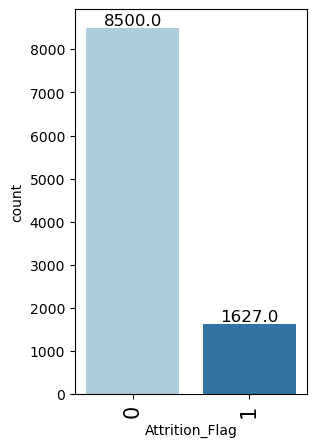

In [ ]:
labeled_barplot(df,'Attrition_Flag')

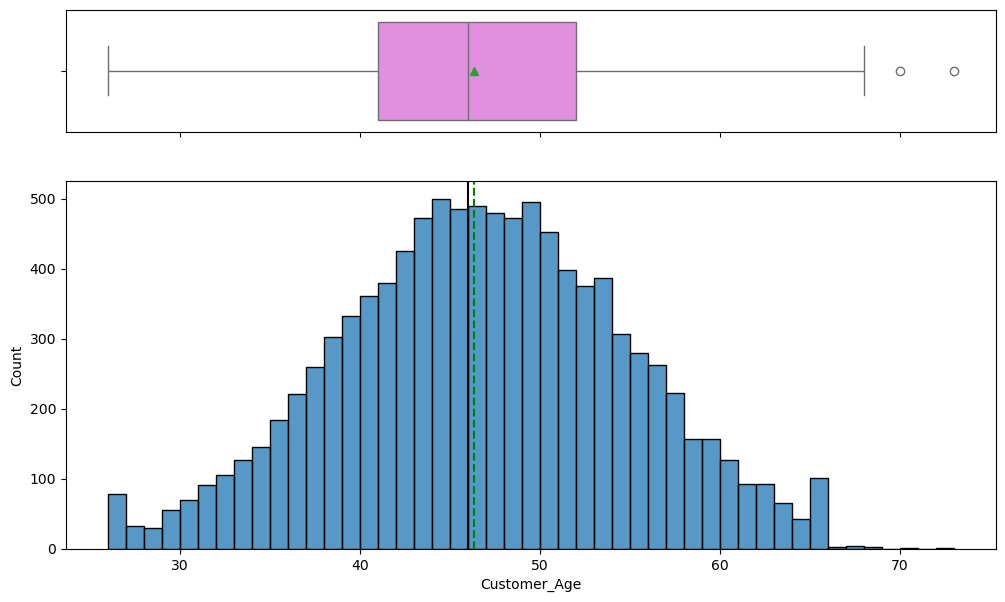

In [ ]:
histogram_boxplot(df,'Customer_Age')

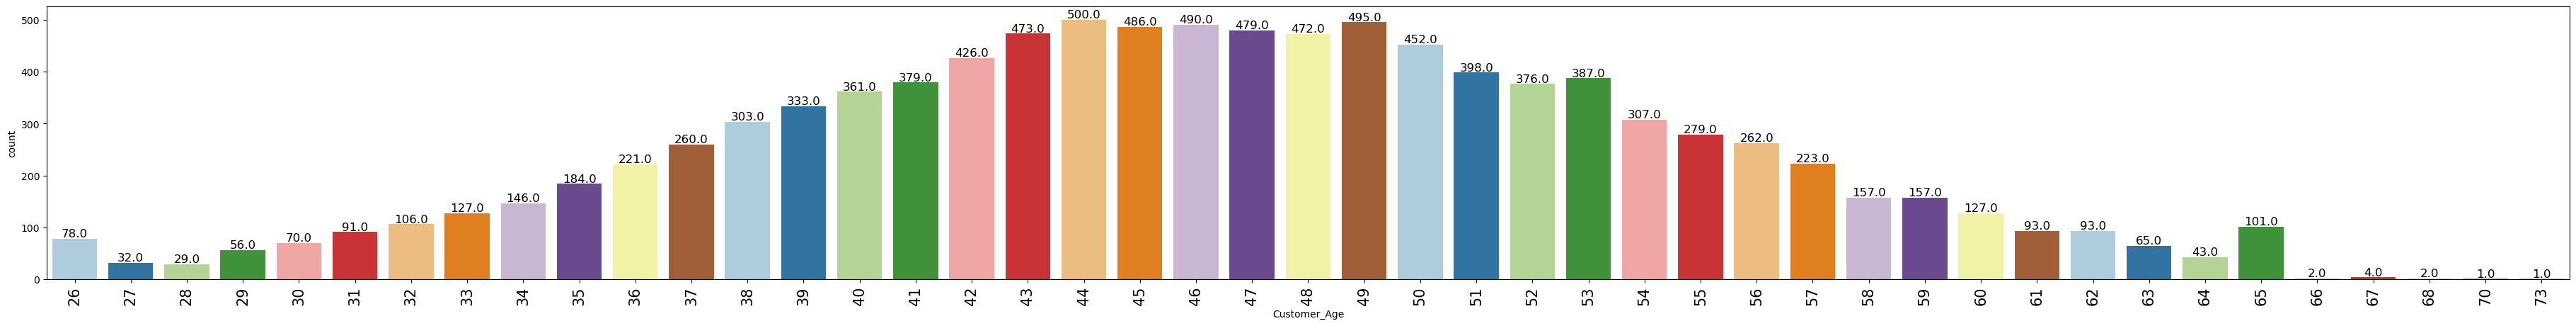

In [ ]:
labeled_barplot(df,'Customer_Age')

The charts suggest the majority of customers are in their late 30s to late 40s, with a long tail extending to older ages (some into the 70s). The distribution is slightly right-skewed, but not dramatically so.

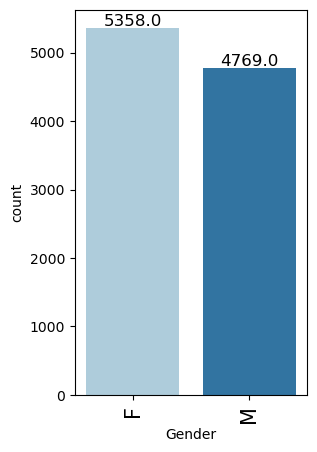

In [ ]:
labeled_barplot(df,'Gender')

There are slightly more female customers than male customers in this dataset (around 53% female vs. 47% male).

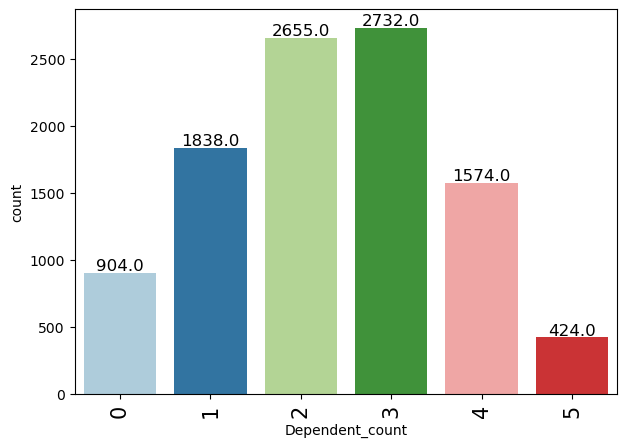

In [ ]:
labeled_barplot(df,'Dependent_count')

The most frequent dependent count is 3, followed closely by 2. Relatively fewer customers have 4 or 5 dependents, and the smallest group has 0 dependents.

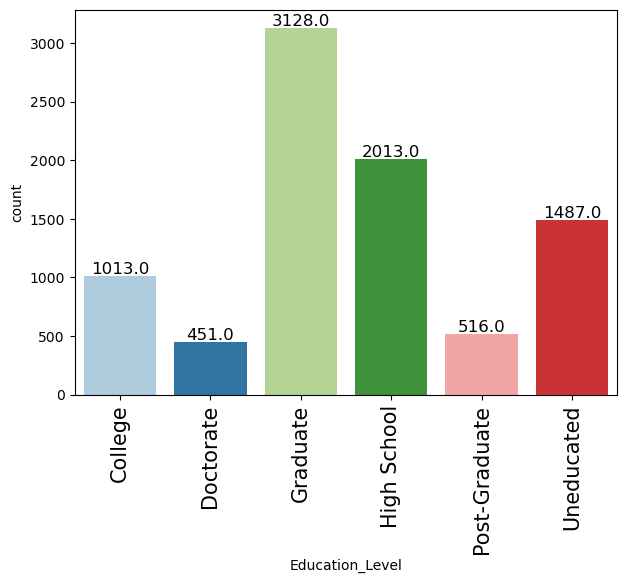

In [ ]:
labeled_barplot(df,'Education_Level')

Most customers report having graduated (roughly 3,128) or at least finished high school (2,013). A noticeable portion (1,487) have not received formal schooling past an “Uneducated” status, while relatively fewer hold a post‐graduate (516) or doctoral degree (451).

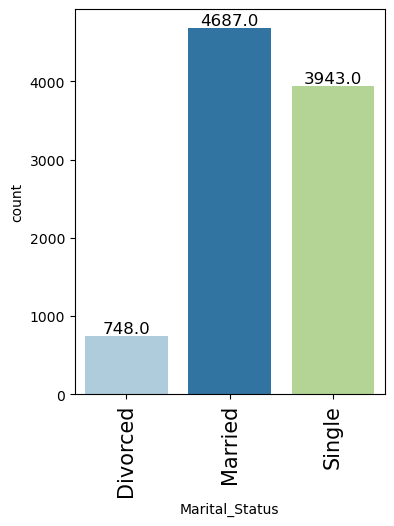

In [ ]:
labeled_barplot(df,'Marital_Status')

The majority of customers are either married (just under half of the total) or single (about 40%), with a smaller minority who are divorced.

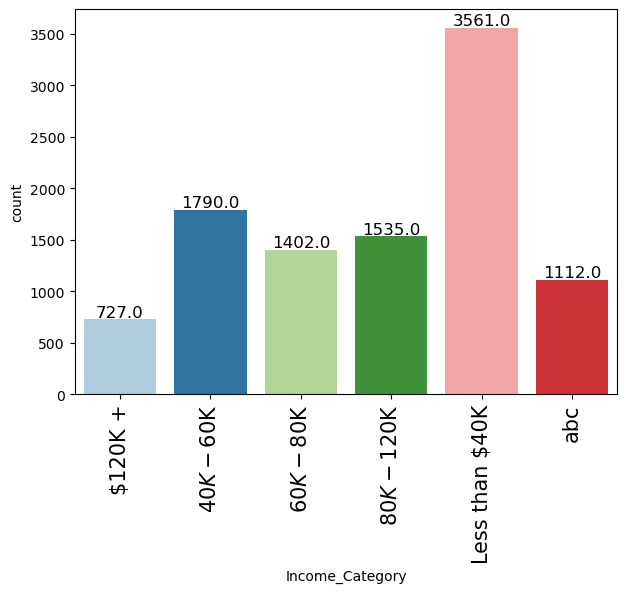

In [ ]:
labeled_barplot(df,'Income_Category')

Overall, the income distribution is skewed toward lower‐to‐middle income brackets, with only a small fraction at the $120K+ level. The “abc” category is a data anomaly or placeholder that may need clarification or cleaning.

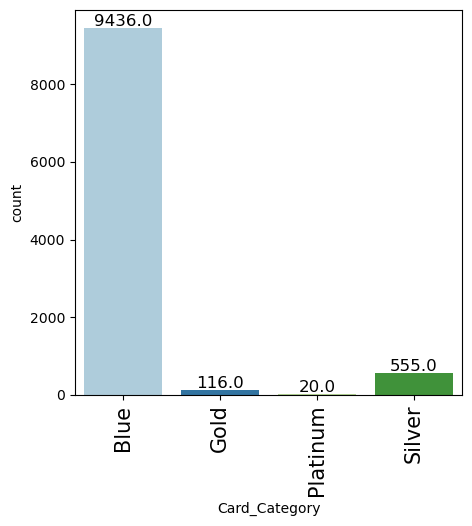

In [ ]:
labeled_barplot(df,'Card_Category')

This suggests that the Blue card is by far the most common or default offering, while higher‐tier (Silver, Gold, Platinum) cards are relatively rare among the customer base.

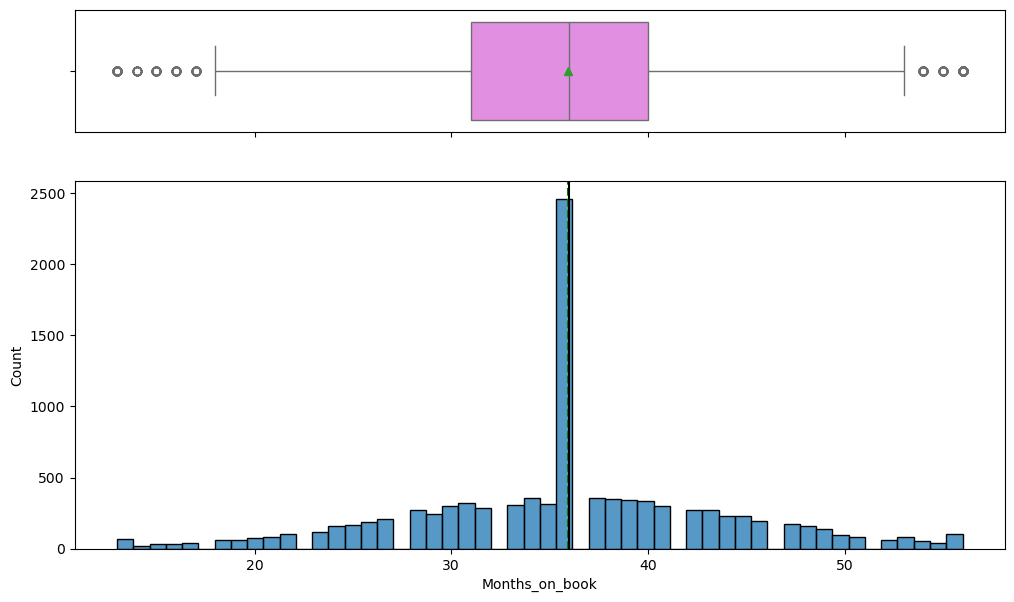

In [ ]:
histogram_boxplot(df,'Months_on_book')

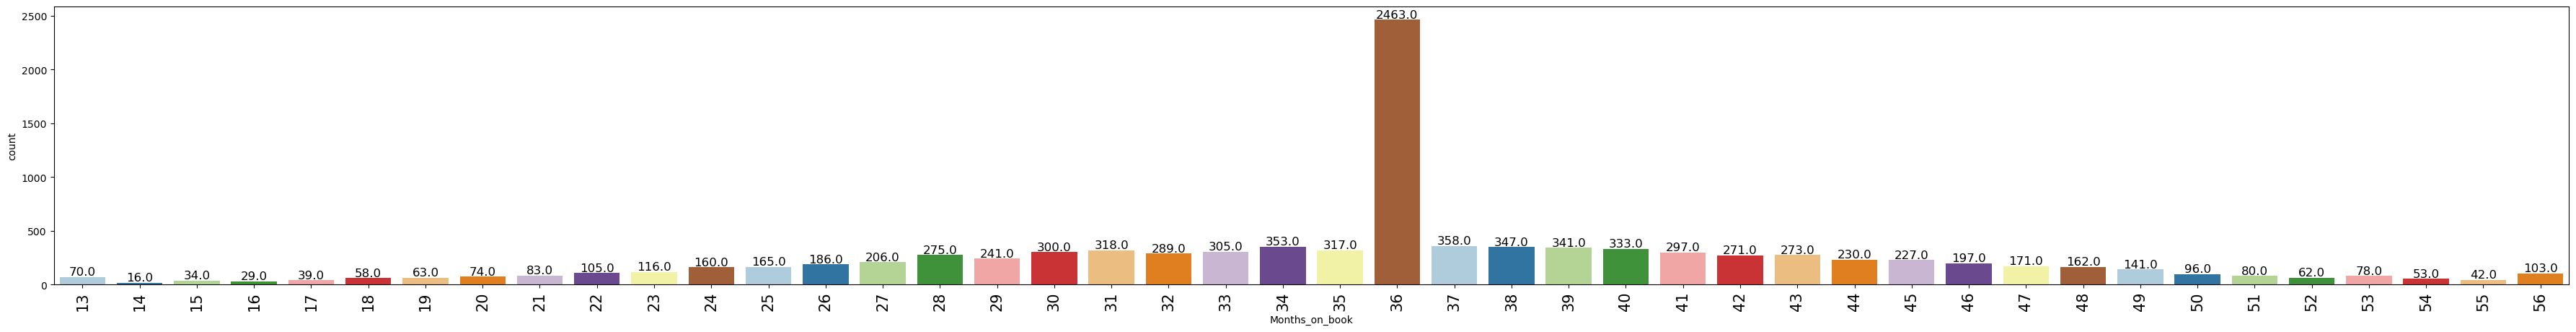

In [ ]:
labeled_barplot(df,'Months_on_book')

Overall, 36 months is the most common tenure, with the bulk of accounts in the 30–40 month range. Only a small fraction of customers have extremely short or long tenures, which appear as outliers on the box plot.

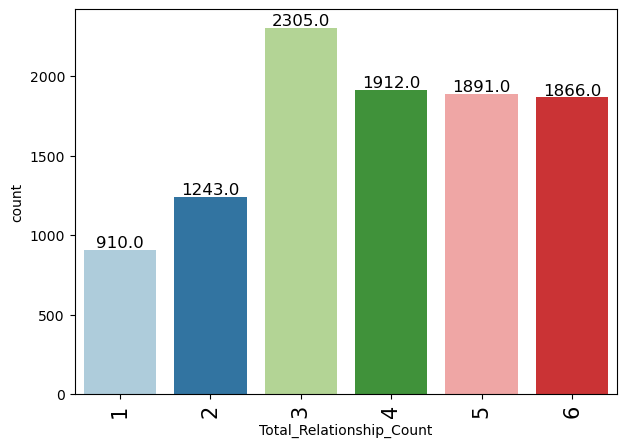

In [ ]:
labeled_barplot(df,'Total_Relationship_Count')

Most customers have 3–4 products, and relatively fewer are on the low (1–2) or high (5–6) ends. This suggests a moderate level of product engagement among the majority of the customer base.

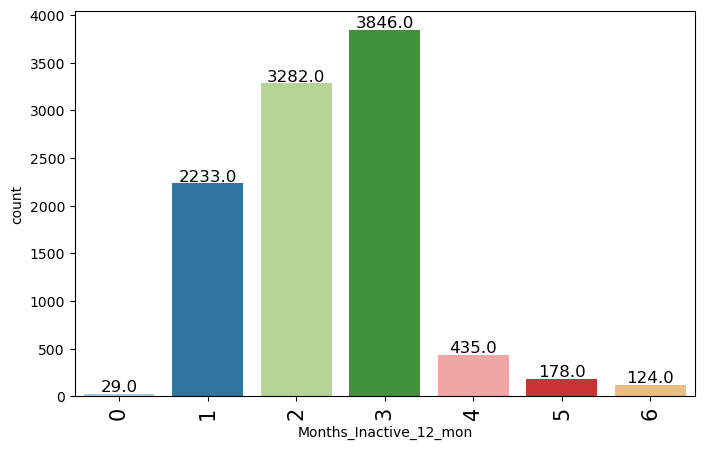

In [ ]:
labeled_barplot(df,'Months_Inactive_12_mon')

In short, mild to moderate inactivity (1–3 months) over the past year is the norm, while long-term inactivity (4–6 months) or zero inactivity is relatively rare in this data.

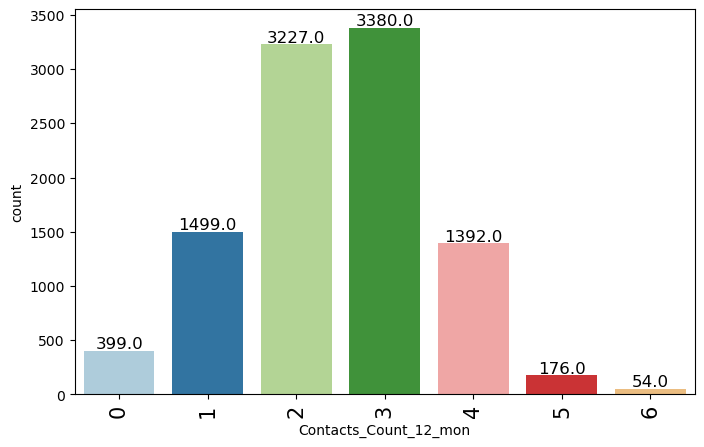

In [ ]:
labeled_barplot(df,'Contacts_Count_12_mon')

In short, the typical customer has 2–3 interactions with the bank annually, while both zero‐contact customers and those with 5–6 contacts are relatively rare.

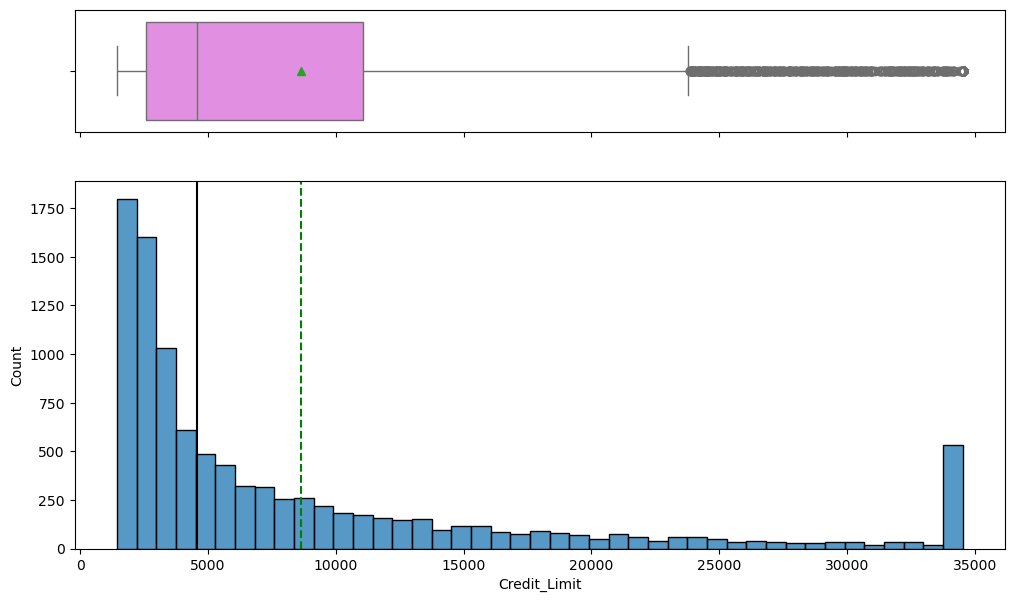

In [ ]:
histogram_boxplot(df,'Credit_Limit')

- Most customers fall into a lower to mid credit‐limit bracket (under 6K–8K).

- A smaller portion have moderately high limits (10K–25K), while a handful have very high limits (30K–35K).

- In short, the distribution is heavily skewed right, with the median well below 5,000 but a mean around 9K–10K, highlighting the impact of relatively few customers with very large credit lines.

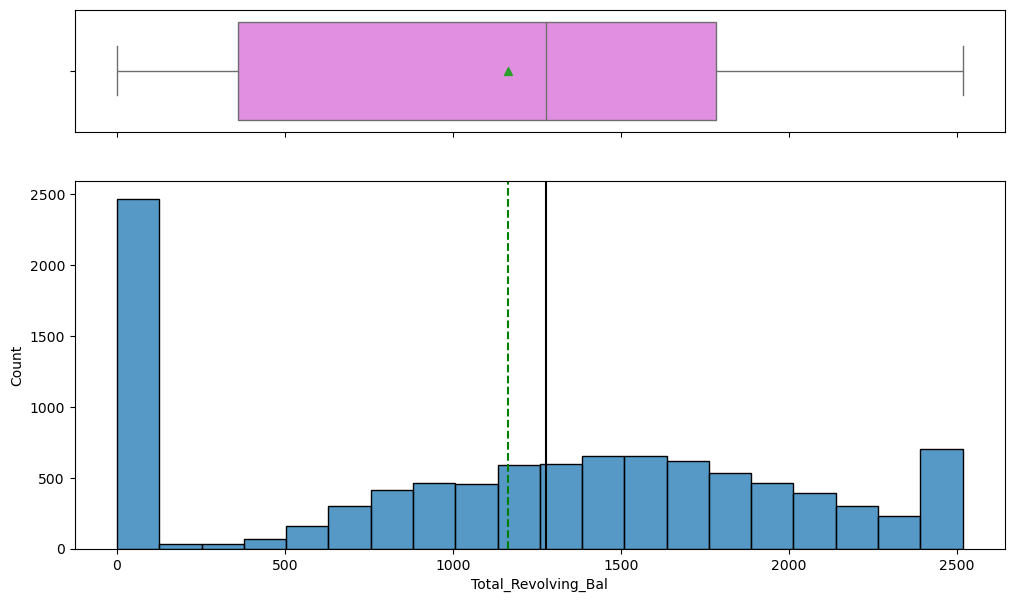

In [ ]:
histogram_boxplot(df,'Total_Revolving_Bal')

Many customers carry no revolving balance at all(they may pay off their bill in full or simply not use the card), but among those who do revolve a balance, amounts can vary widely, with a median around 900–1,000 and some customers carrying as high as 2,500.

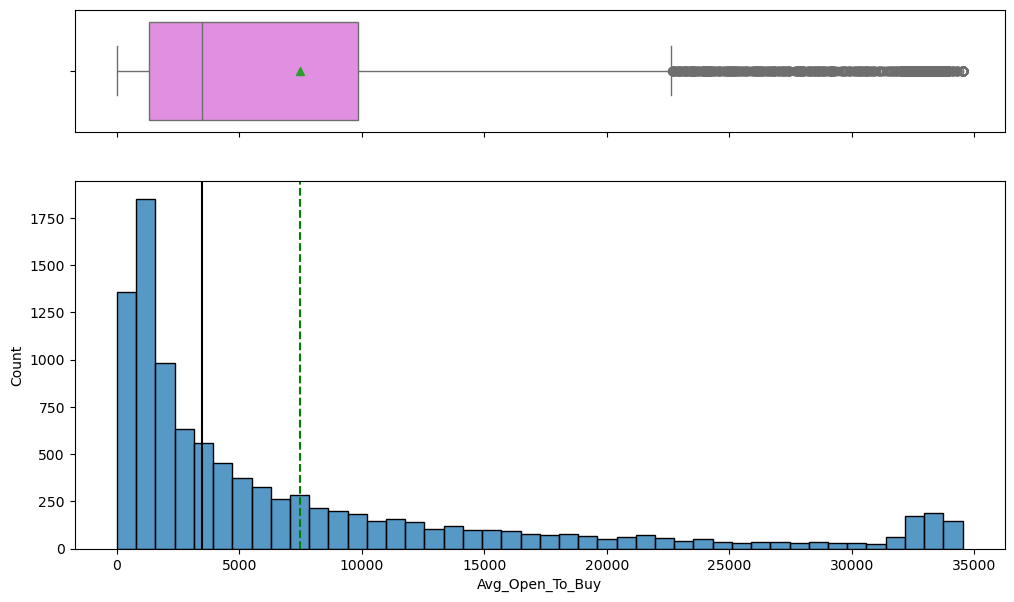

In [ ]:
histogram_boxplot(df,'Avg_Open_To_Buy')

- Customers with lower credit lines or higher utilization naturally have a smaller open‐to‐buy amount.

- Those with high credit limits and relatively low usage can have large open‐to‐buy values, creating the long right tail.

- In short, most customers have a few thousand dollars of credit remaining, but a handful have very large unused credit lines—driving up the average and producing a strong right skew.

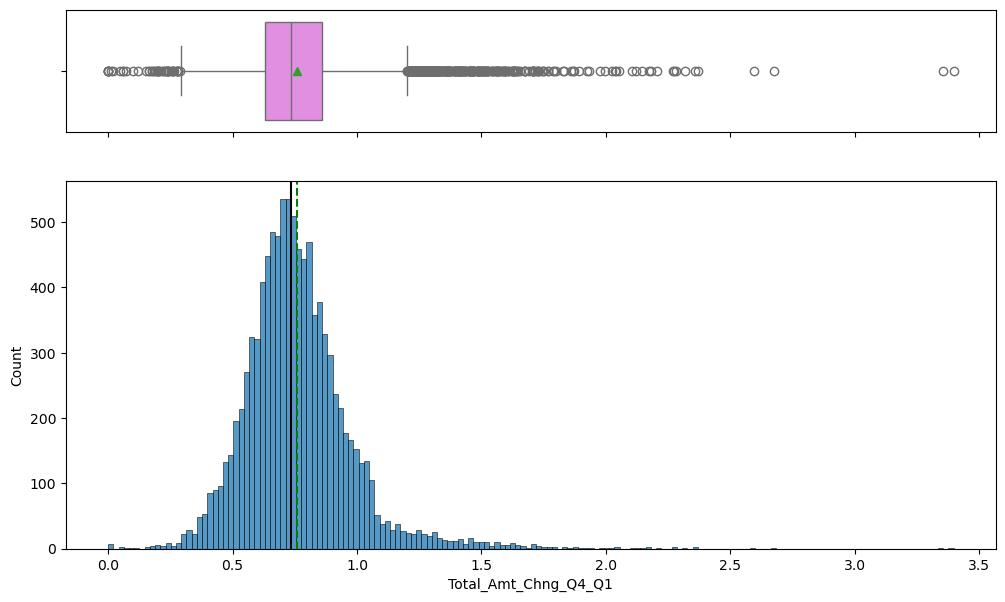

In [ ]:
histogram_boxplot(df,'Total_Amt_Chng_Q4_Q1')

- The median is somewhere around 0.7–0.8, below 1.0, implying that more than half of customers decreased or modestly changed their transaction amounts from Q1 to Q4.
- most customers see Q4 transaction amounts somewhat less than or close to those in Q1, but a smaller segment show very large increases—enough to pull the mean near 1.0 and create a notable right tail.

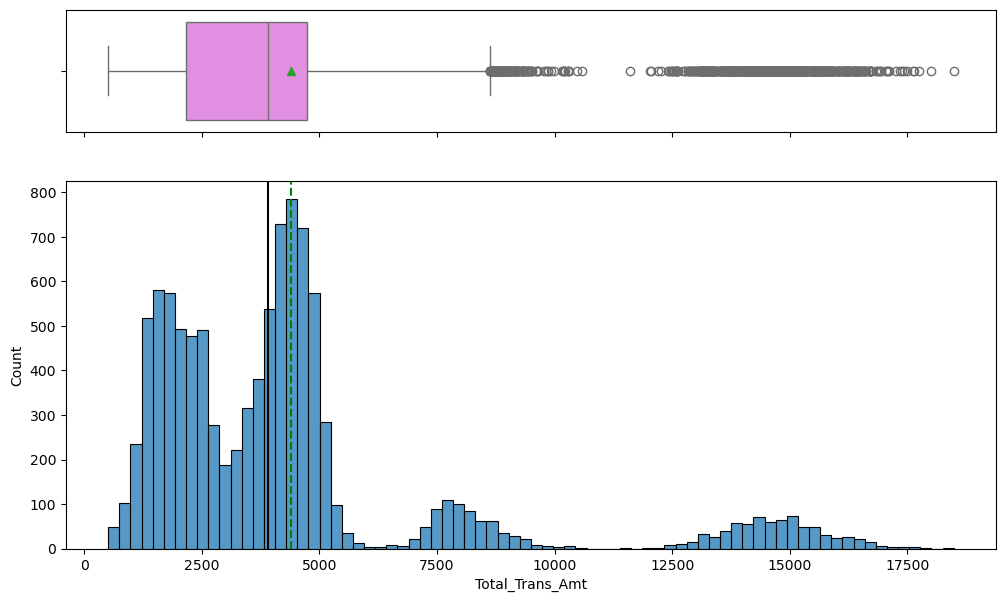

In [ ]:
histogram_boxplot(df,'Total_Trans_Amt')

- The data is right‐skewed, but more notably it’s multi‐modal—suggesting distinct spending tiers or usage segments in the customer base.
- Most customers fall within the lower‐to‐moderate transaction brackets (2,000–6,000), but there is a meaningful minority that spends significantly more throughout the year.
- In short, Total_Trans_Amt has at least two or three noticeable “usage clusters,” with a dominant group around 5K per year, plus smaller but important segments of heavier spenders in the 8K–9K and 12K+ ranges.

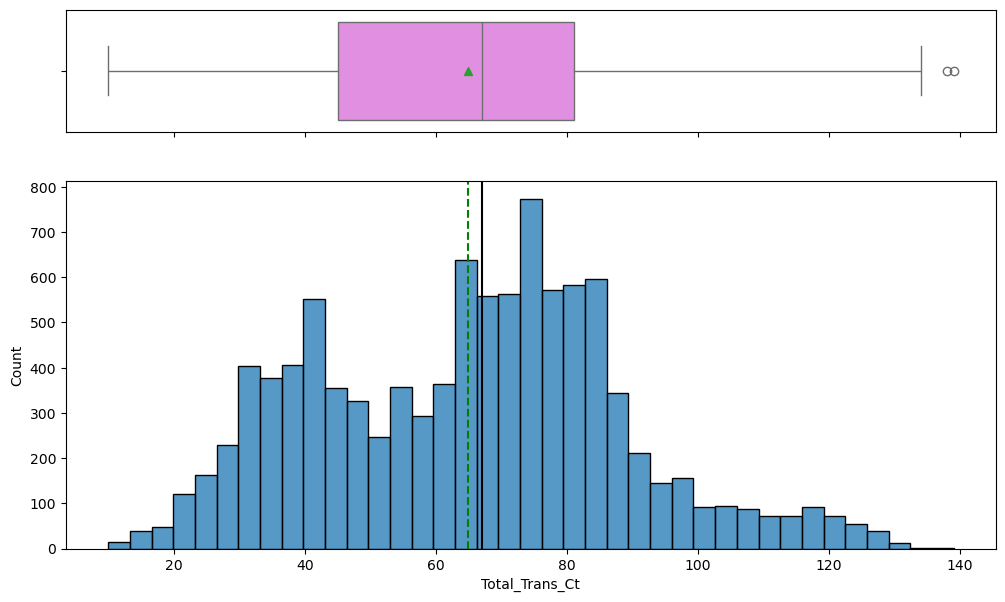

In [ ]:
histogram_boxplot(df,'Total_Trans_Ct')

- Most customers make 40–80 transactions per year, which is a moderate range of monthly usage.
- A smaller subset have very low (under 20) or very high (over 100) transaction counts, creating a moderate right skew.
- In short, 60–70 transactions per year is typical, but customers do vary widely, from infrequent users to those making more than 100 transactions annually.

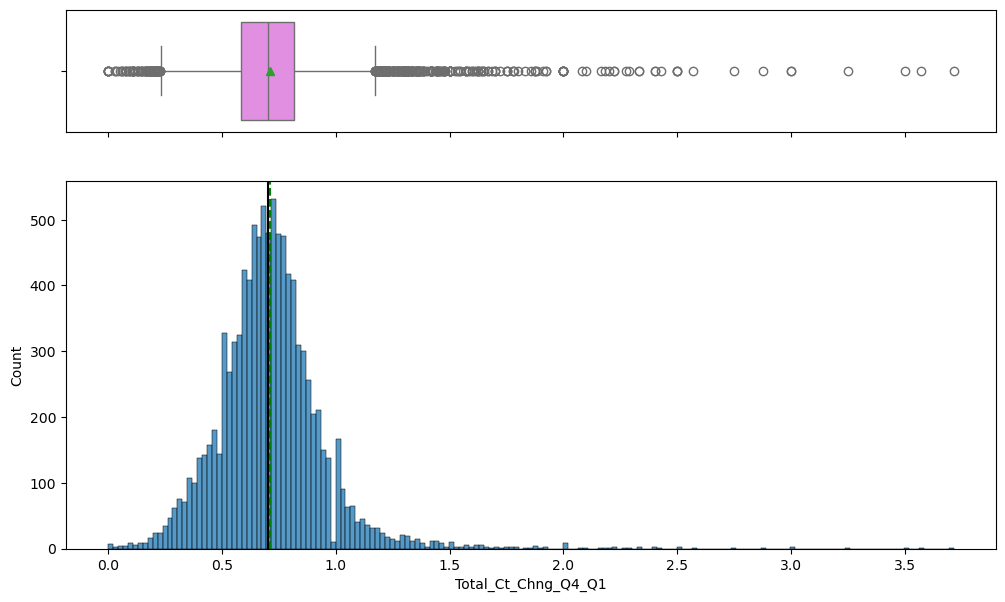

In [ ]:
histogram_boxplot(df,'Total_Ct_Chng_Q4_Q1')

Most customers show a moderate decrease or near‐equal Q4 vs. Q1 transaction count, while a noticeable minority exhibit very large increases (ratios > 2) or near‐zero Q4 usage (ratios close to 0).

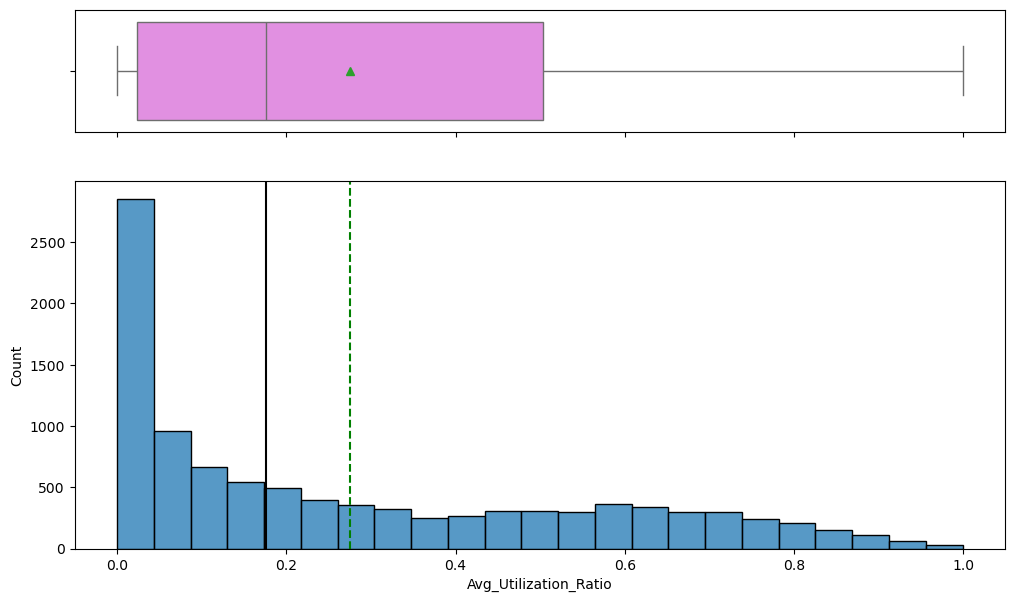

In [ ]:
histogram_boxplot(df,'Avg_Utilization_Ratio')

Most customers appear to have low utilization (less than 20%), but there is a smaller group who consistently use a large fraction of their credit—creating a right‐skewed distribution.

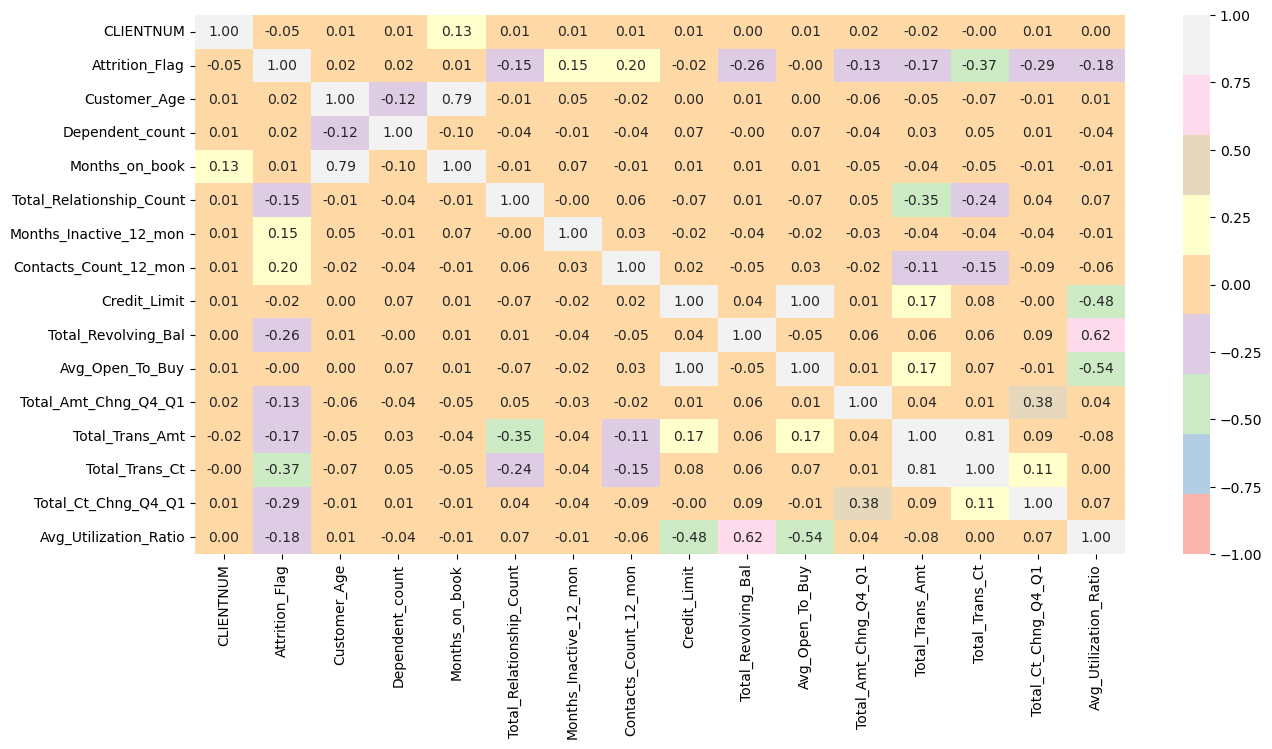

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Pastel1")
plt.show()

- Many of these correlations align with intuitive banking behavior—for instance, higher engagement (transactions) tends to reduce churn, and higher credit limits lower average utilization.
- “Customer_Age” and “Months_on_book” are almost redundant (r ≈ 0.79), so in a predictive model, you might not need both without careful feature‐engineering.
- Most correlations with Attrition_Flag are moderate at best; churn is likely influenced by a combination of multiple factors rather than a single standout variable.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def calculate_cramers_v(x, y):
    """
    Calculate Cramér’s V for two categorical pandas Series x and y.

    Parameters:
    - x: pandas Series, first categorical variable
    - y: pandas Series, second categorical variable

    Returns:
    - Cramér’s V value, a measure of association between the two variables.
    """
    # Create a contingency table for the two variables
    confusion_matrix = pd.crosstab(x, y)

    # Perform the chi-squared test on the contingency table
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)

    # Total number of observations
    n = confusion_matrix.sum().sum()

    # Number of rows and columns
    r, k = confusion_matrix.shape

    # Compute and return Cramér’s V
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


def get_sorted_cramers_v_scores(dataframe, target_column,
                                bin_numeric=True, numeric_bins=10,
                                exclude_columns=None):
    """
    Calculate and return sorted Cramér’s V scores for all features against a target column.

    This version includes:
      - Optional discretization (binning) of numeric features with many unique values.
      - The ability to exclude specific columns (e.g., unique identifiers).

    Parameters:
    - dataframe: pandas DataFrame containing features and target variable.
    - target_column: str, name of the target column to compare other features against.
    - bin_numeric: bool (default True). If True, numeric features with many unique values will be binned.
    - numeric_bins: int (default 10). The number of bins to use when binning numeric features.
    - exclude_columns: list or set (default None). Columns to be excluded from the analysis.

    Returns:
    - A sorted pandas DataFrame with columns 'Feature' and 'Cramér’s V Score', in descending order.
    """
    scores = {}

    # Ensure exclude_columns is a set for faster lookup if provided
    if exclude_columns is None:
        exclude_columns = set()
    else:
        exclude_columns = set(exclude_columns)

    for column in dataframe.columns:
        if column == target_column or column in exclude_columns:
            continue

        series = dataframe[column]

        # Skip potential identifier columns: if each value is unique, ignore this column.
        if series.nunique() == len(series):
            continue

        # For numeric columns, optionally bin the data if there are many unique values.
        if pd.api.types.is_numeric_dtype(series):
            if bin_numeric and series.nunique() > numeric_bins:
                # Use pd.cut to discretize into bins.
                # The 'duplicates' parameter ensures that if bin edges are not unique,
                # the binning will still work.
                series = pd.cut(series, bins=numeric_bins, duplicates='drop')

        # Calculate Cramér’s V for this (possibly discretized) feature versus the target.
        try:
            scores[column] = calculate_cramers_v(series, dataframe[target_column])
        except Exception as e:
            print(f"Error calculating Cramér’s V for column {column}: {e}")
            scores[column] = np.nan

    # Create a DataFrame from the scores dictionary and sort it in descending order.
    scores_df = pd.DataFrame(scores.items(), columns=['Feature', 'Cramér’s V Score'])
    sorted_scores_df = scores_df.sort_values(by='Cramér’s V Score', ascending=False).reset_index(drop=True)

    return sorted_scores_df

sorted_cramers_v_scores = get_sorted_cramers_v_scores(df, 'Attrition_Flag', exclude_columns=['CLIENTNUM'])

print("Sorted Cramér’s V Scores:")
print(sorted_cramers_v_scores)

Sorted Cramér’s V Scores:
                     Feature  Cramér’s V Score
0             Total_Trans_Ct             0.459
1        Total_Revolving_Bal             0.403
2            Total_Trans_Amt             0.327
3        Total_Ct_Chng_Q4_Q1             0.315
4      Avg_Utilization_Ratio             0.243
5      Contacts_Count_12_mon             0.241
6     Months_Inactive_12_mon             0.198
7       Total_Amt_Chng_Q4_Q1             0.186
8   Total_Relationship_Count             0.167
9               Credit_Limit             0.044
10              Customer_Age             0.038
11                    Gender             0.037
12           Education_Level             0.037
13            Months_on_book             0.036
14           Income_Category             0.036
15           Avg_Open_To_Buy             0.036
16           Dependent_count             0.031
17            Marital_Status             0.024
18             Card_Category             0.015


1.	Transaction‐Related Features Dominate
    - Total_Trans_Ct (0.459) ranks highest, meaning the number of transactions per year most strongly predicts whether a customer will remain or attrite.
    - Total_Revolving_Bal (0.403), Total_Trans_Amt (0.327), and Total_Ct_Chng_Q4_Q1 (0.315) also score high. These revolve around how much the customer is spending (amount) or how usage changes between quarters.
    - Taken together, these suggest engagement with the card (transaction volume, balance carried, spending changes) strongly correlates with churn.
2.	Utilization & Contact Frequency Are Next
    - Avg_Utilization_Ratio (0.243) and Contacts_Count_12_mon (0.241) also show moderately strong associations.
    - Customers who use more of their credit line or have more frequent interactions with the bank may have distinctive churn patterns, possibly indicating higher engagement (and typically lower churn) or, in some cases, more frequent service calls if they’re dissatisfied (potentially higher churn).
3.	Demographics & Card Details Are Weaker Predictors
    - Variables like Credit_Limit (0.044), Customer_Age (0.038), Education_Level (0.037), Income_Category (0.036), and Card_Category (0.015) have much lower Cramér’s V scores.
    - This means demographic factors and the specific card type alone do not predict churn nearly as strongly as usage behavior does.

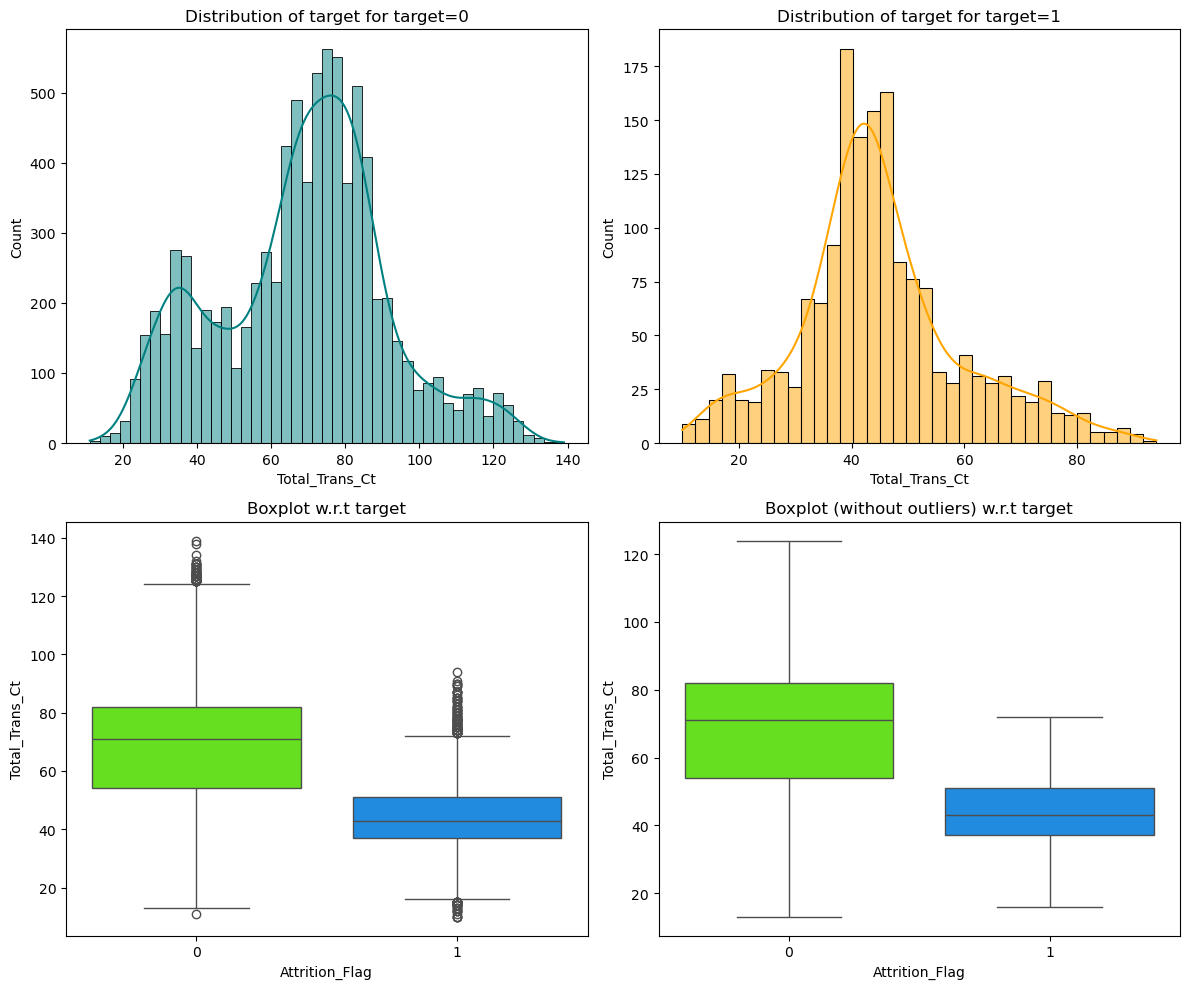

In [ ]:
distribution_plot_wrt_target(df, "Total_Trans_Ct", "Attrition_Flag")

This confirms Total_Trans_Ct is a strong churn predictor—customers who use their card more frequently (more engaged) are much less likely to close their accounts.

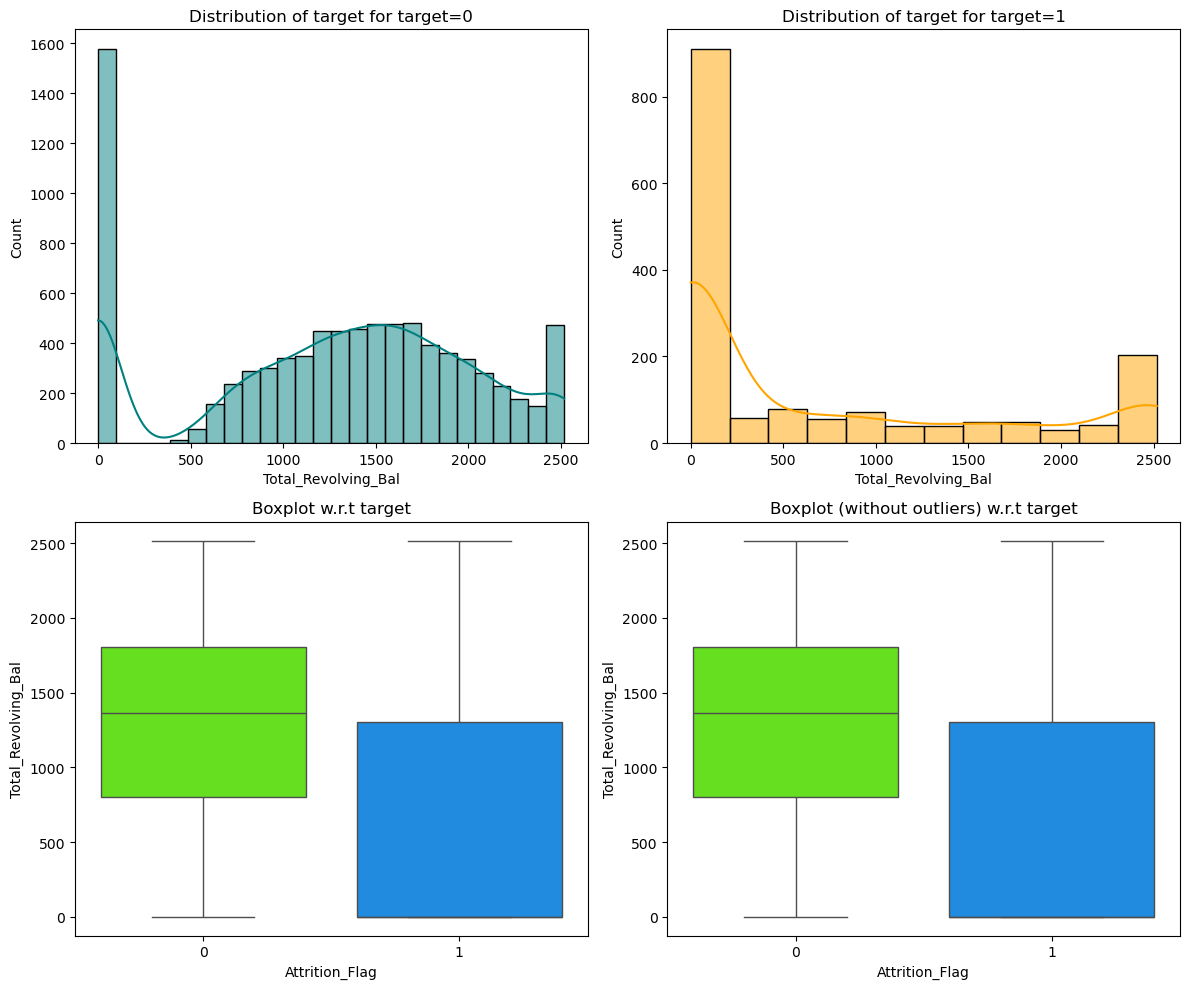

In [ ]:
distribution_plot_wrt_target(df, "Total_Revolving_Bal", "Attrition_Flag")

Overall, these plots reinforce that card usage (revolving a balance) is linked to retention—customers who actually carry a balance tend to stay, likely because the card is integral to their day‐to‐day finances.

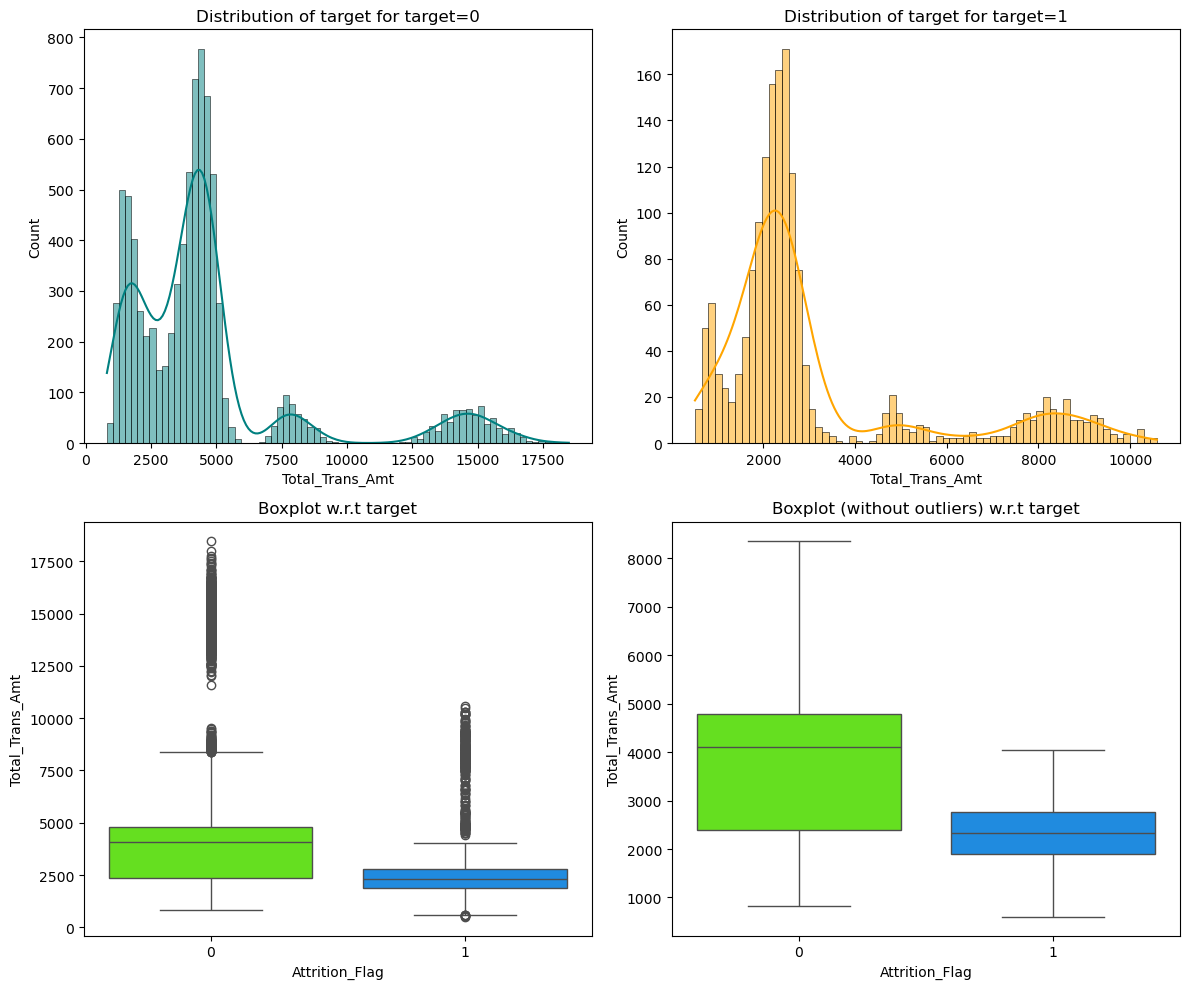

In [ ]:
distribution_plot_wrt_target(df, "Total_Trans_Amt", "Attrition_Flag")

- Customers who engage heavily with their card (spend more) tend to remain, whereas those with relatively low total usage are more prone to closing the account.
- Total_Trans_Amt is another strong indicator of card engagement—and hence a key predictor of churn.

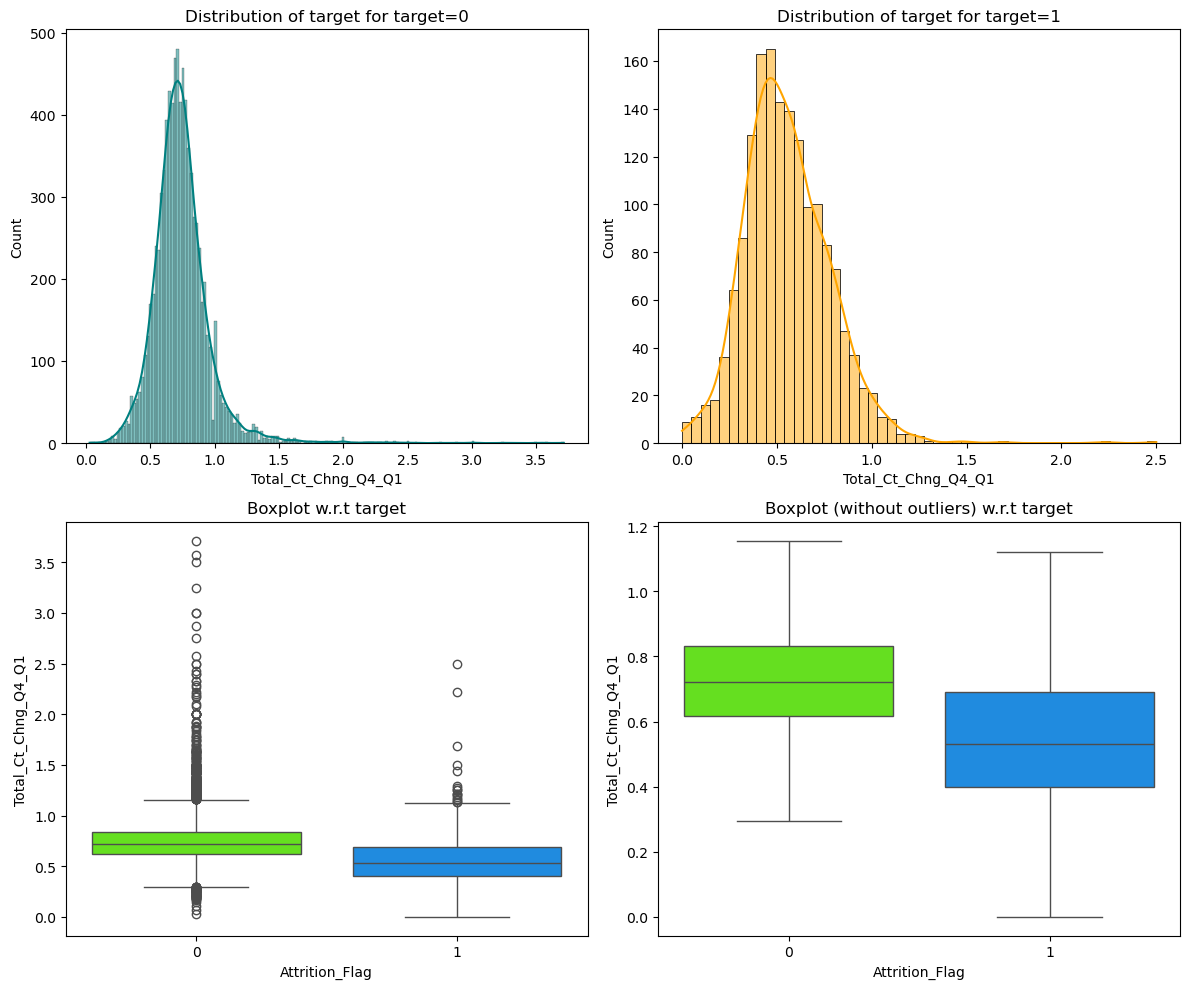

In [ ]:
distribution_plot_wrt_target(df, "Total_Ct_Chng_Q4_Q1", "Attrition_Flag")

The data suggests that customers whose transaction activity declines significantly over the year are at higher risk of attrition, whereas those who maintain or increase usage in Q4 are far more likely to remain with the bank.

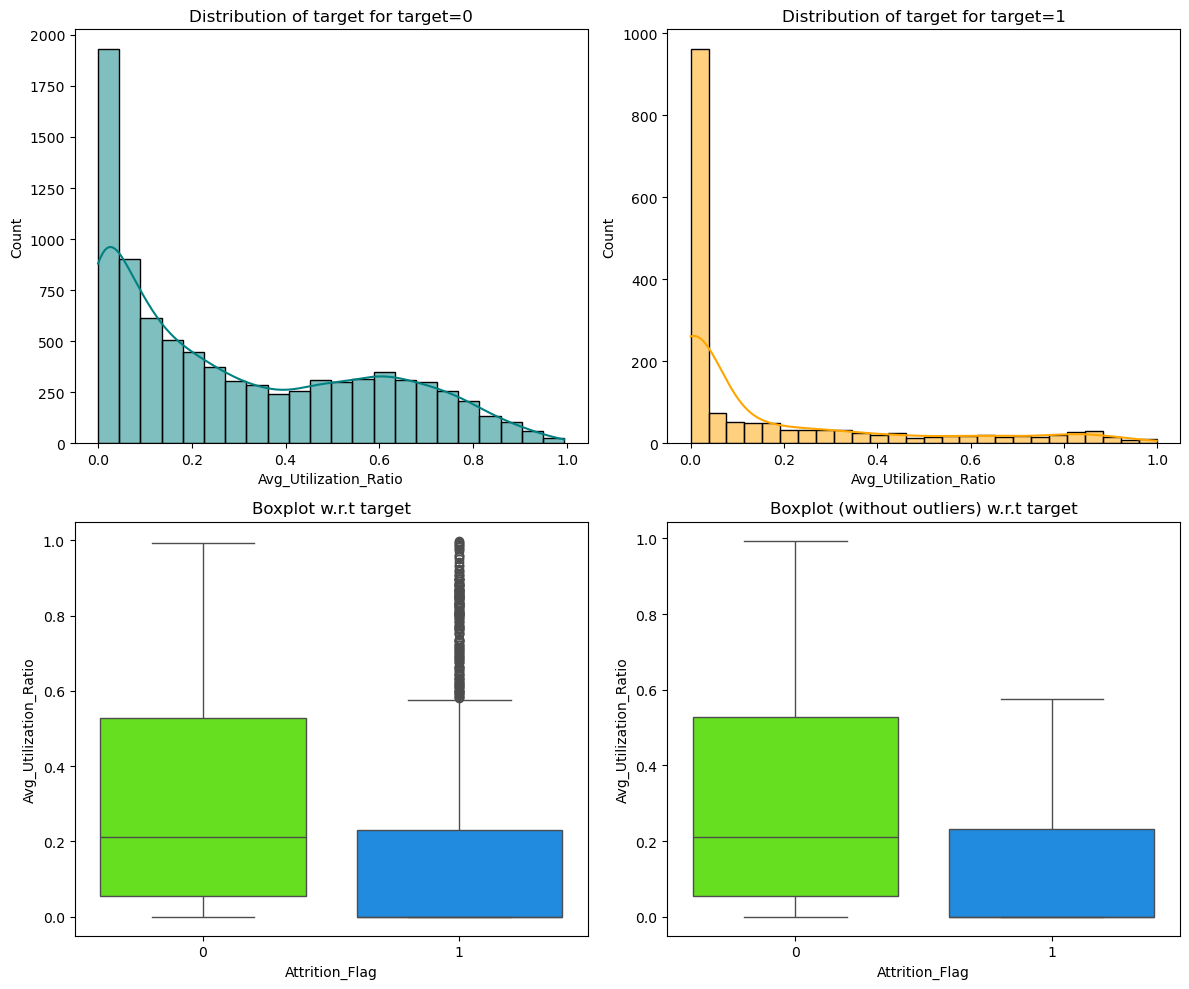

In [ ]:
distribution_plot_wrt_target(df, "Avg_Utilization_Ratio", "Attrition_Flag")

- Low (or zero) average utilization can be a hallmark of disengaged cardholders who see little need to keep the account open.
- Conversely, customers who use their credit line regularly—even if modestly—tend to maintain the card, aligning with other findings that higher engagement correlates with lower attrition.

Attrition_Flag            0     1    All
Contacts_Count_12_mon                   
All                    8500  1627  10127
3                      2699   681   3380
2                      2824   403   3227
4                      1077   315   1392
1                      1391   108   1499
5                       117    59    176
6                         0    54     54
0                       392     7    399
------------------------------------------------------------------------------------------------------------------------


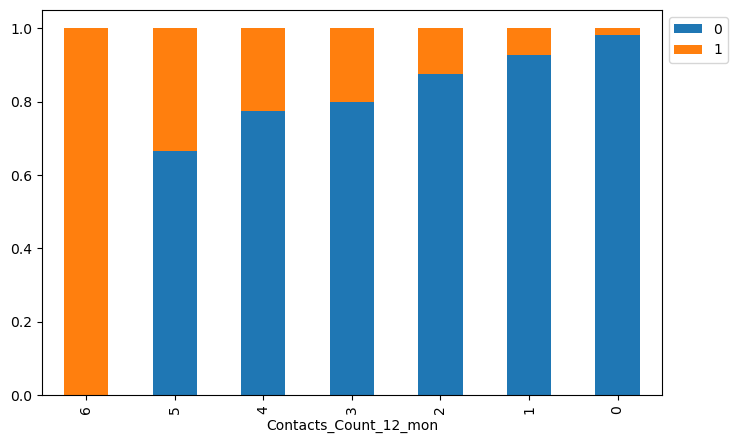

In [ ]:
stacked_barplot(df, "Contacts_Count_12_mon", "Attrition_Flag")

The pattern indicates a U‐shaped relationship where very low contact customers (no calls) often stay, whereas high contact customers show significantly higher churn. This underscores the importance of monitoring frequent‐contact customers—those multiple interactions might be a sign of frustration or dissatisfaction heading toward attrition.

Attrition_Flag             0     1    All
Months_Inactive_12_mon                   
All                     8500  1627  10127
3                       3020   826   3846
2                       2777   505   3282
4                        305   130    435
1                       2133   100   2233
5                        146    32    178
6                        105    19    124
0                         14    15     29
------------------------------------------------------------------------------------------------------------------------


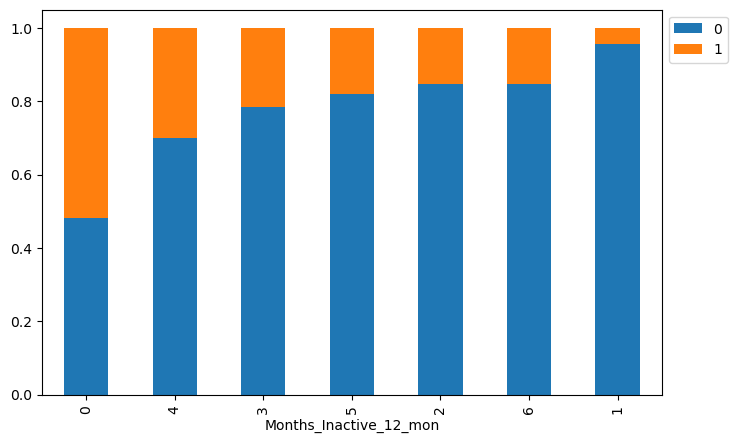

In [ ]:
stacked_barplot(df, "Months_Inactive_12_mon", "Attrition_Flag")

The chart does not simply rise with more inactivity. Instead, 0 months stands out with a surprisingly large churn proportion—potentially reflecting active but unhappy customers. The rest follow a more intuitive pattern: moderate inactivity often correlates with moderate churn, though there are exceptions at both high and low extremes.

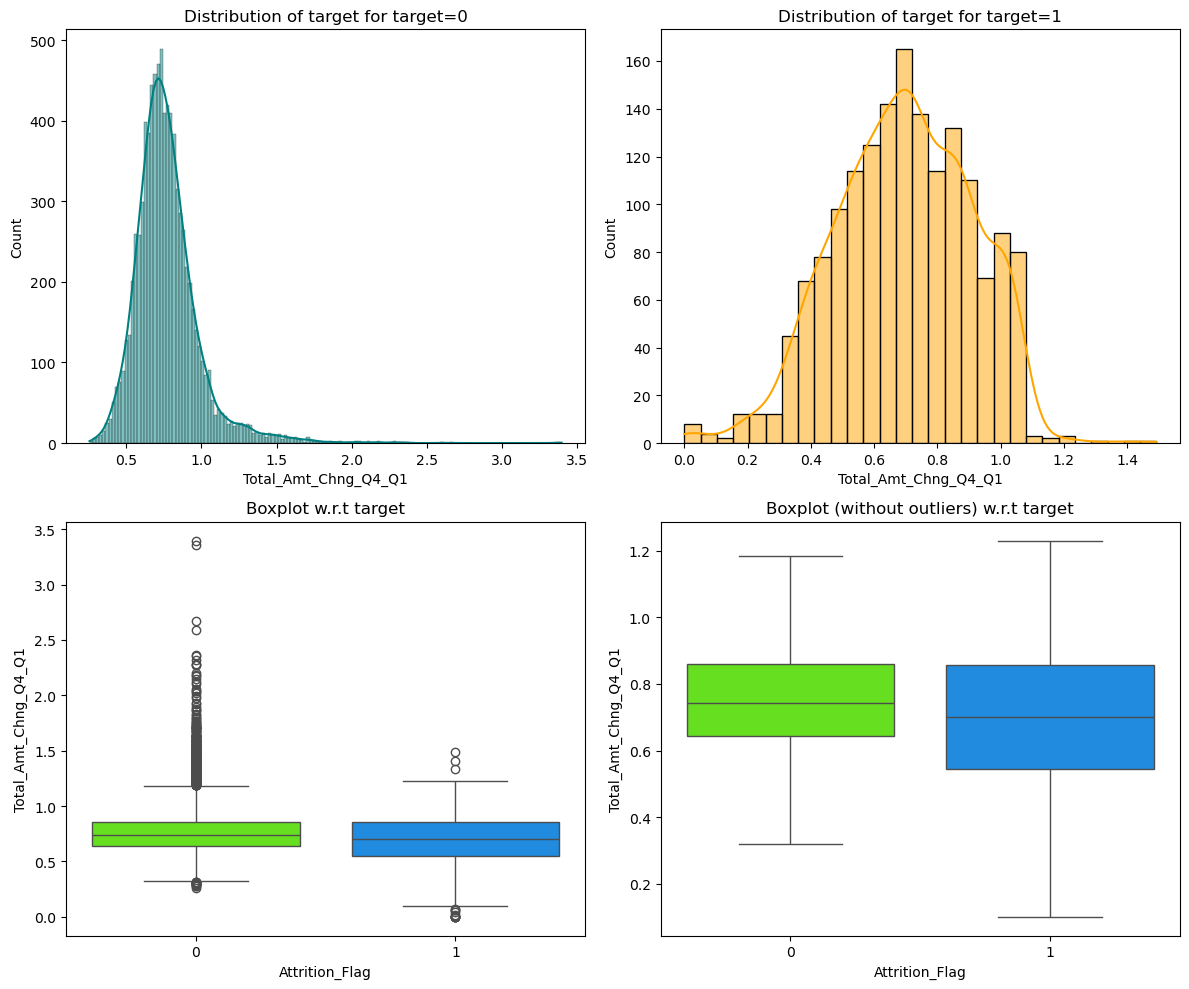

In [ ]:
distribution_plot_wrt_target(df, "Total_Amt_Chng_Q4_Q1", "Attrition_Flag")

Customers whose transaction amounts drop off from Q1 to Q4 appear more prone to attrition, whereas those who maintain or boost spending across quarters generally stay.

Attrition_Flag               0     1    All
Total_Relationship_Count                   
All                       8500  1627  10127
3                         1905   400   2305
2                          897   346   1243
1                          677   233    910
5                         1664   227   1891
4                         1687   225   1912
6                         1670   196   1866
------------------------------------------------------------------------------------------------------------------------


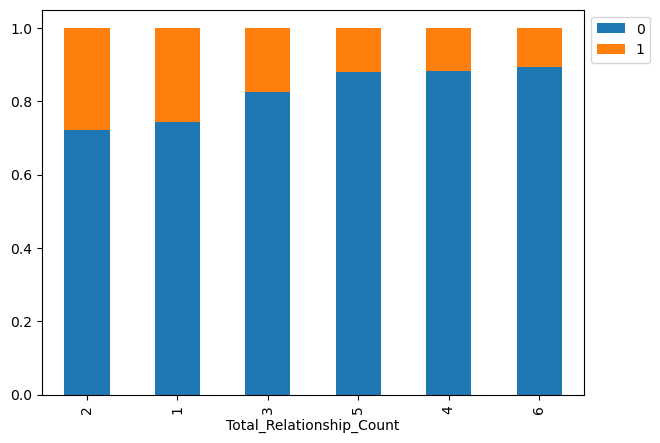

In [ ]:
stacked_barplot(df, "Total_Relationship_Count", "Attrition_Flag")

The chart shows a downward trend in churn as Total_Relationship_Count increases. This is a common pattern in banking—customers with multiple accounts or services are typically the most loyal.

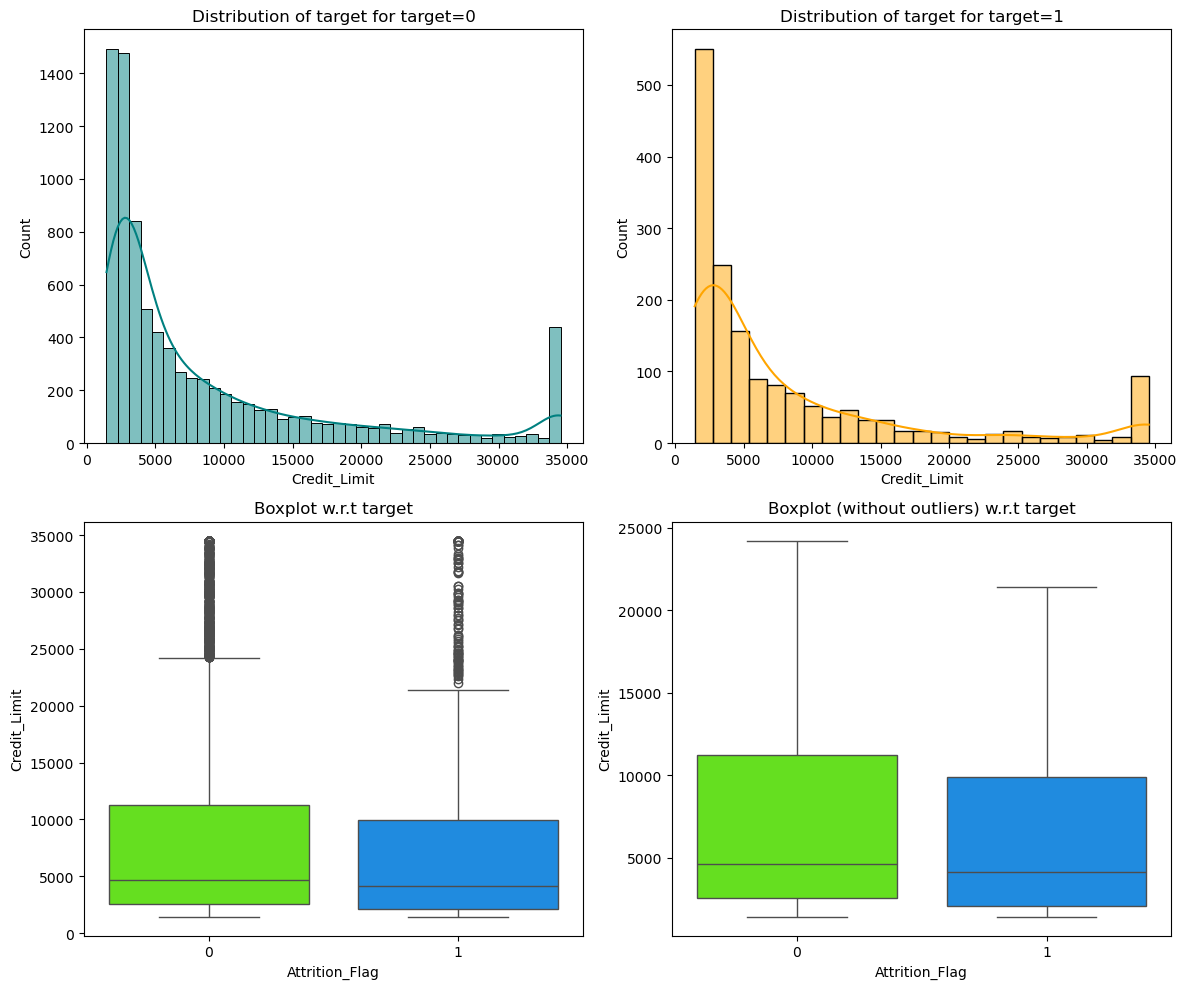

In [ ]:
distribution_plot_wrt_target(df, "Credit_Limit", "Attrition_Flag")

While higher credit limits slightly lean toward non‐churners, the effect is nowhere near as strong as, say, transaction frequency or spending levels.

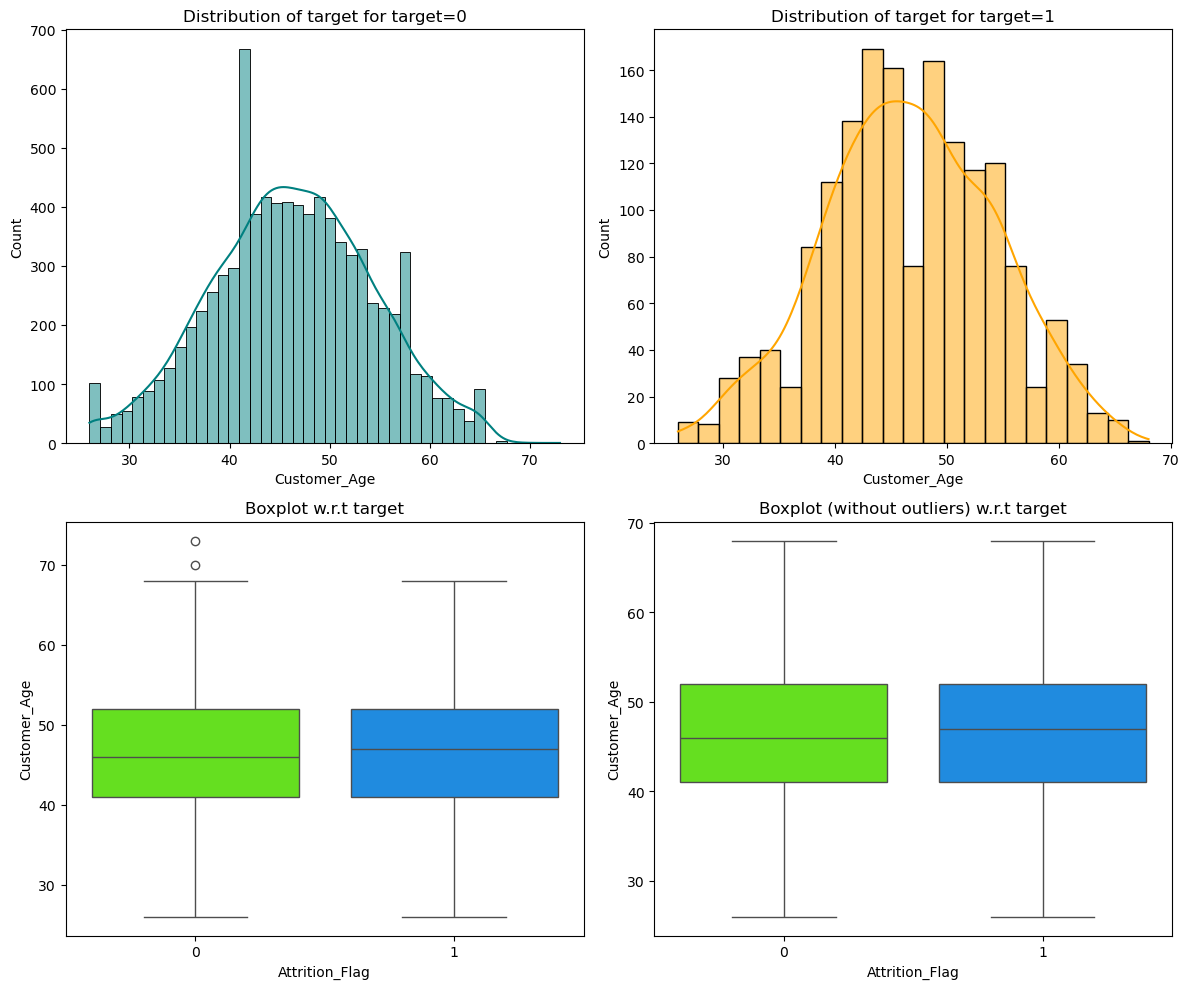

In [ ]:
distribution_plot_wrt_target(df, "Customer_Age", "Attrition_Flag")

Customer_Age shows only a modest relationship to attrition compared to more impactful engagement metrics.

Attrition_Flag     0     1    All
Gender                           
All             8500  1627  10127
F               4428   930   5358
M               4072   697   4769
------------------------------------------------------------------------------------------------------------------------


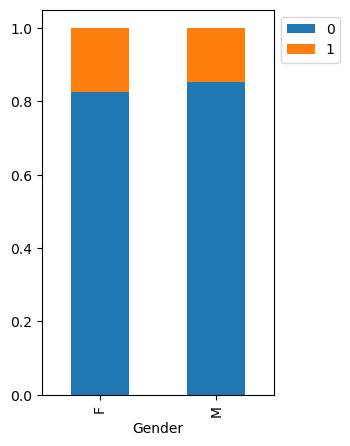

In [ ]:
stacked_barplot(df, "Gender", "Attrition_Flag")

While there may be a slight variance, gender does not show a large gap in churn risk—both groups behave similarly in terms of retention vs. attrition.

Attrition_Flag      0     1   All
Education_Level                  
All              7237  1371  8608
Graduate         2641   487  3128
High School      1707   306  2013
Uneducated       1250   237  1487
College           859   154  1013
Doctorate         356    95   451
Post-Graduate     424    92   516
------------------------------------------------------------------------------------------------------------------------


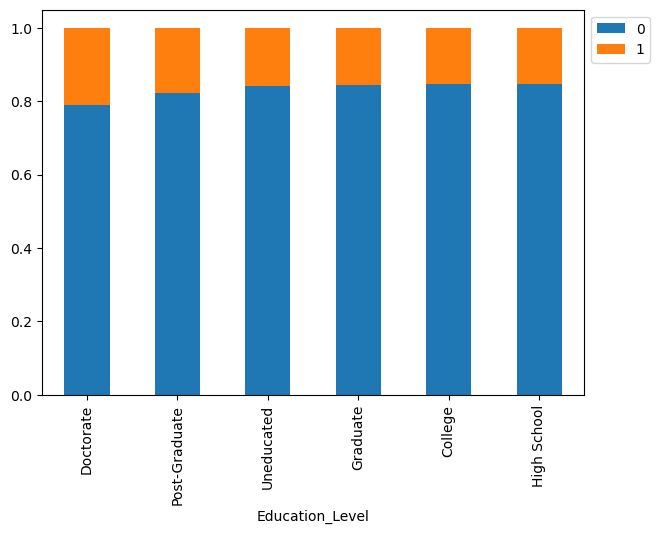

In [ ]:
stacked_barplot(df, "Education_Level", "Attrition_Flag")

Education level exhibits only a small influence on churn risk, and the pattern is far less pronounced than what we’ve observed for transaction‐driven features.

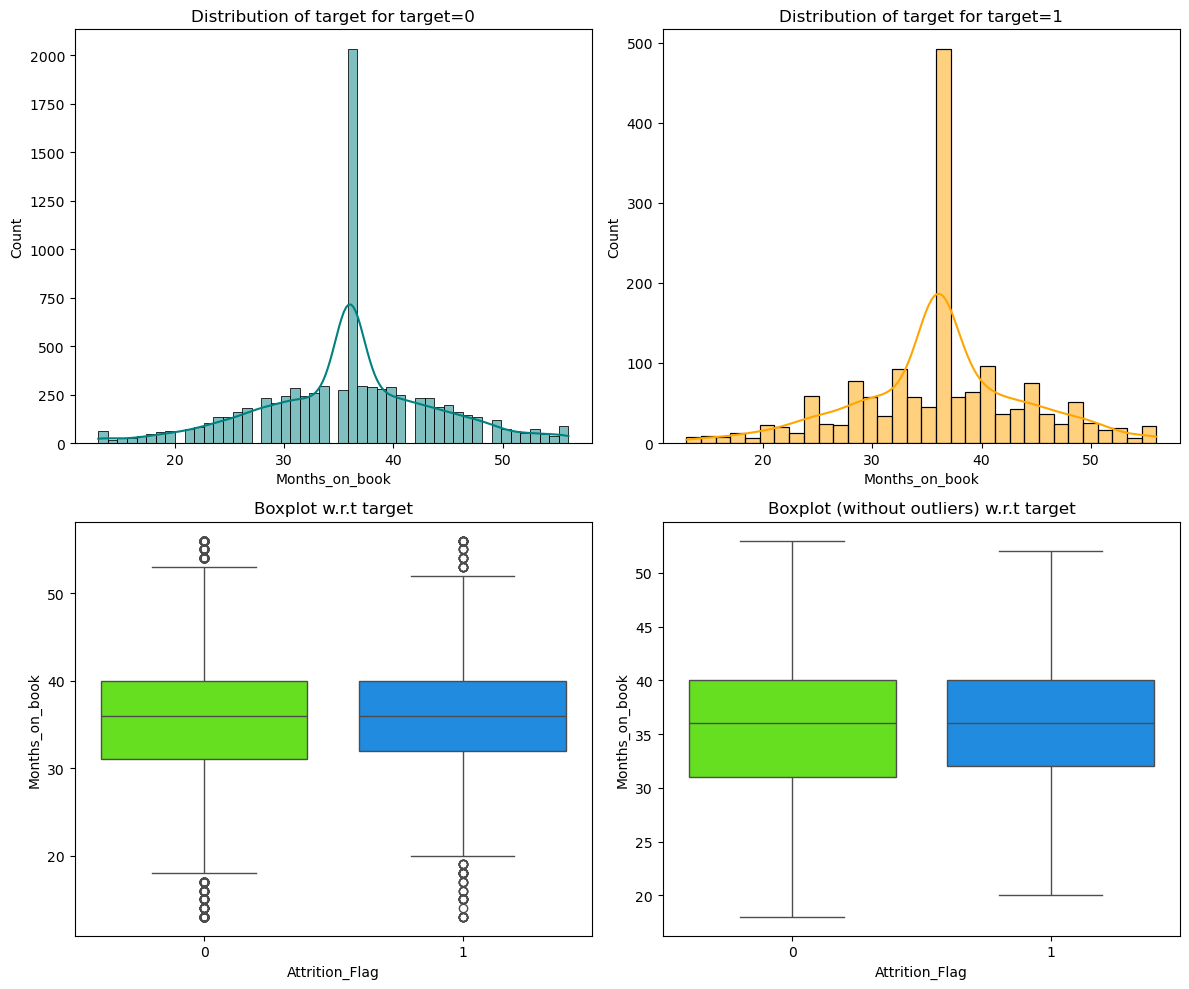

In [ ]:
distribution_plot_wrt_target(df, "Months_on_book", "Attrition_Flag")

Months_on_book shows a minimal difference between churners and non‐churners, suggesting that simple tenure length isn’t the key driver of attrition in this dataset.

Attrition_Flag      0     1    All
Income_Category                   
All              8500  1627  10127
Less than $40K   2949   612   3561
$40K - $60K      1519   271   1790
$80K - $120K     1293   242   1535
$60K - $80K      1213   189   1402
abc               925   187   1112
$120K +           601   126    727
------------------------------------------------------------------------------------------------------------------------


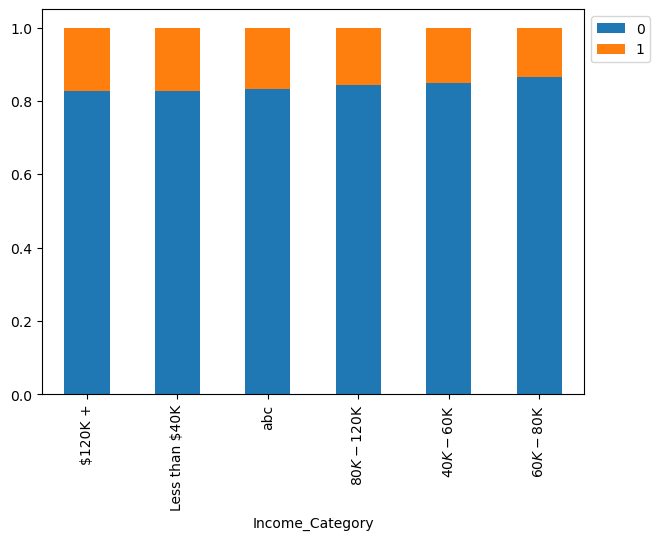

In [ ]:
stacked_barplot(df, "Income_Category", "Attrition_Flag")

While higher or lower incomes might slightly tilt churn probability, it’s relatively minor compared to how actively the customer uses their card.

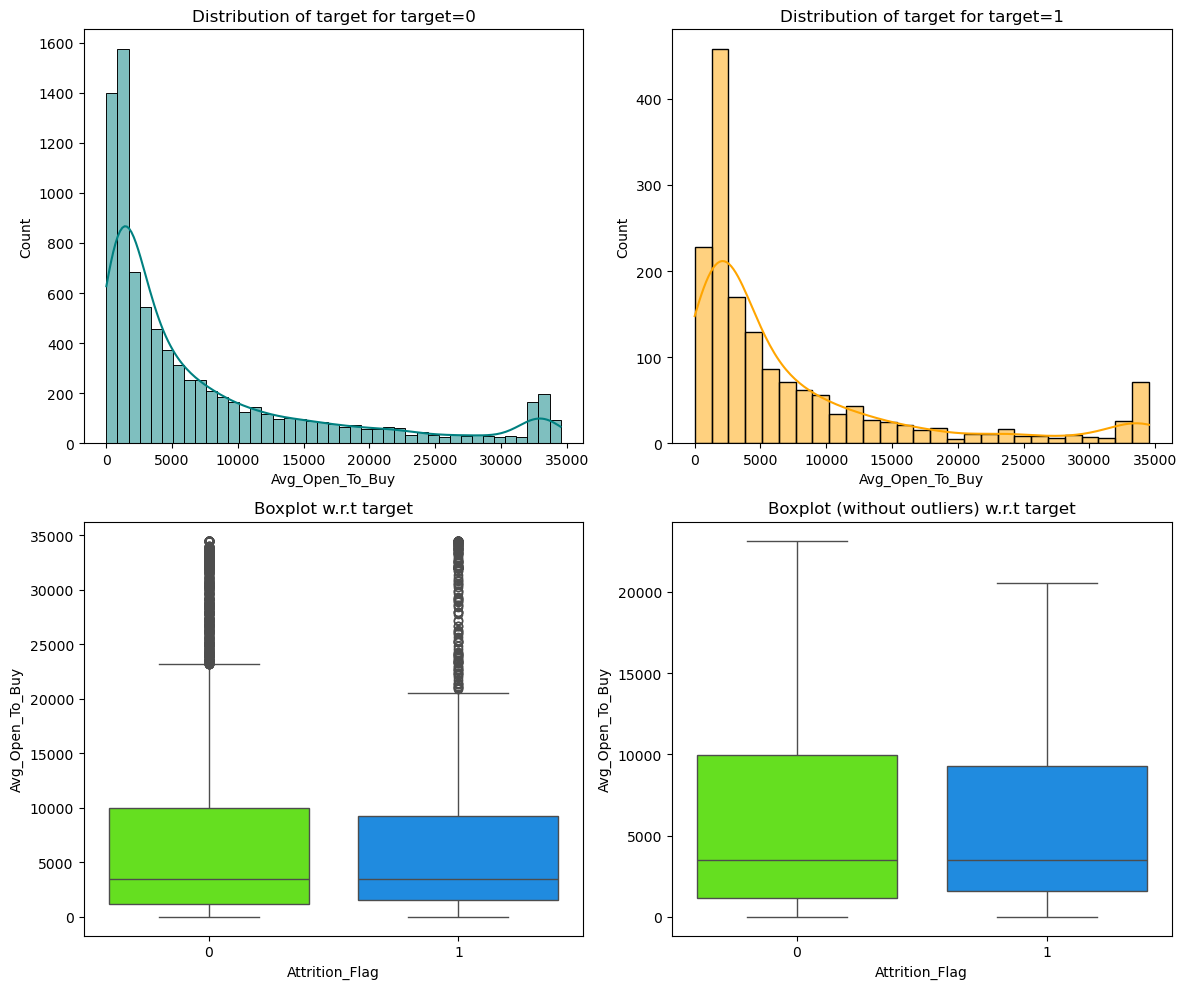

In [ ]:
distribution_plot_wrt_target(df, "Avg_Open_To_Buy", "Attrition_Flag")

Gaving more available credit correlates weakly with retention, but this feature does not separate churners and non‐churners nearly as strongly as transaction behavior does.

Attrition_Flag      0     1    All
Dependent_count                   
All              8500  1627  10127
3                2250   482   2732
2                2238   417   2655
1                1569   269   1838
4                1314   260   1574
0                 769   135    904
5                 360    64    424
------------------------------------------------------------------------------------------------------------------------


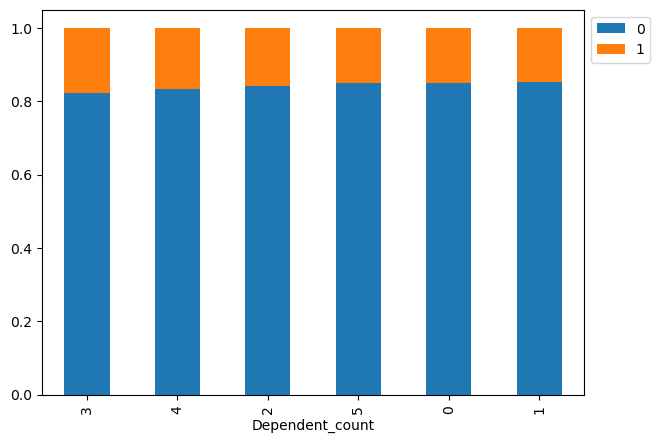

In [ ]:
stacked_barplot(df, "Dependent_count", "Attrition_Flag")

Like several other demographic factors (e.g., Gender, Education_Level), Dependent_count alone does not markedly separate churners from non‐churners.

Attrition_Flag     0     1   All
Marital_Status                  
All             7880  1498  9378
Married         3978   709  4687
Single          3275   668  3943
Divorced         627   121   748
------------------------------------------------------------------------------------------------------------------------


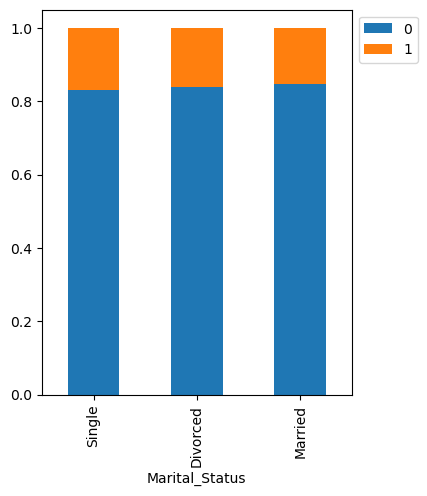

In [ ]:
stacked_barplot(df, "Marital_Status", "Attrition_Flag")

Like Dependent_count or Income_Category, Marital_Status doesn’t markedly separate churners from non‐churners.

Attrition_Flag     0     1    All
Card_Category                    
All             8500  1627  10127
Blue            7917  1519   9436
Silver           473    82    555
Gold              95    21    116
Platinum          15     5     20
------------------------------------------------------------------------------------------------------------------------


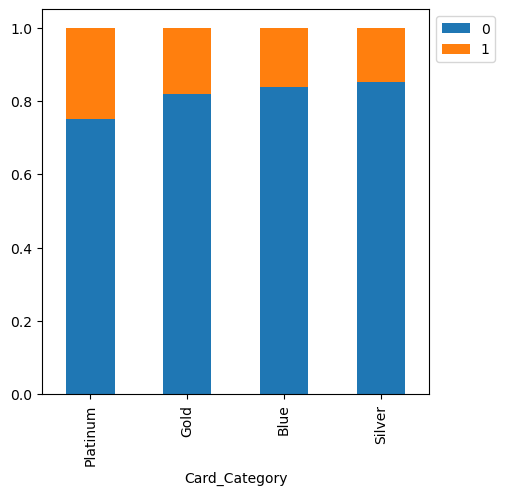

In [ ]:
stacked_barplot(df, "Card_Category", "Attrition_Flag")

Holding a certain card is not as strong a churn determinant as how actively the customer uses it.

#### Overall Insights

**Transaction‐Based Metrics Dominate**
- Customers with higher total transactions (count/amount) or higher/larger increases from Q1 to Q4 are far less likely to churn.
- Low usage, particularly a drop in activity (few transactions or falling amounts), correlates strongly with attrition.
  
**Credit & Utilization**
- Carrying a higher revolving balance or having a moderate/high utilization often indicates engagement and correlates with lower churn.
- Conversely, having zero usage (no revolving balance) or extremely low utilization tends to coincide with higher churn.
  
**Demographic Features (e.g., Gender, Age, Education, Income)**
- Show relatively weak differences in churn rates. While there may be minor variations (e.g., slightly older churners, small differences by education or income), these are far less predictive than usage variables.
  
**Months_on_book (Tenure)**
- Has a narrow spread around 3 years for most customers, with no sharp divide between churners and non‐churners.
  
**Contacts & Inactivity**
- High contacts (5–6 calls in 12 months) often indicate service issues or dissatisfaction—leading to higher churn.
- 0 months of inactivity paradoxically also showed a sizable churn fraction, potentially reflecting active but unhappy customers.
  
**Multiple Products**
- A higher Total_Relationship_Count (4, 5, or 6 products) typically lowers churn, indicating more “sticky” engagement with the bank.

#### Answers to Specific Questions

**1.	How is the total transaction amount distributed?**
- Multi‐modal: Large clusters around 2K–6K, with smaller peaks around 8K–9K and 12K+ for heavier spenders. Right‐skewed but with clear subgroups.
- Non‐churners tend to have higher total transaction amounts (often 4K–5K+).

**2.	What is the distribution of the level of education of customers?**
- Graduate is the largest category, followed by High School and Uneducated. College, Post‐Graduate, and Doctorate each have smaller shares.
- Churn proportions across education levels are fairly similar, so education alone is not a major churn determinant.

**3.	What is the distribution of the level of income of customers?**
- “Less than 40K” is the biggest single bracket, with sizable groups also in 40K–60K, 60K–80K, and 80K–120K. A small number are in 120K+.
- One “abc” category indicates missing or invalid data.
- Like education, income shows only slight differences in churn rates.

**4.	How does the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer’s account status (Attrition_Flag)?**
- Non‐churners cluster near or above 0.8–1.0, indicating stable or increasing Q4 usage relative to Q1. Many even exceed 1.5, meaning a big increase.
- Churners skew toward 0.5–0.7, suggesting a notable drop in usage from Q1 to Q4.

**5.	How does the number of months a customer was inactive (Months_Inactive_12_mon) vary by account status?**
- 3 months of inactivity is most common overall.
- Surprisingly, 0 months inactive has a sizeable churn fraction (possibly customers leaving despite being fully active).
- Moderate inactivity (1–3 months) often correlates with moderate churn; 5–6 months also shows a moderately higher churn rate.

**6.	What attributes have a strong correlation with each other?**
- Total_Trans_Amt & Total_Trans_Ct (approx 0.80): More transactions generally mean higher total spend.
- Credit_Limit & Avg_Open_To_Buy (approx 0.60): Larger credit lines allow for more available credit.
- Months_on_book & Customer_Age (approx 0.79): Older customers often have longer tenure.
- Avg_Utilization_Ratio & Avg_Open_To_Buy (negative correlation around -0.54): As utilization rises, open‐to‐buy shrinks.

## Data Pre-processing

In [ ]:
# Drop the 'CLIENTNUM' column from the DataFrame as it is likely unnecessary for analysis
df.drop('CLIENTNUM', inplace=True, axis=1)

### Outlier Percentage Calculation and Display

In [ ]:
# Select numeric columns from the DataFrame for outlier analysis
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the first quartile (Q1) and third quartile (Q3) for each numeric column
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

# Compute the interquartile range (IQR) as the difference between Q3 and Q1
IQR = Q3 - Q1

# Define the boundaries for outliers (1.5 times the IQR below Q1 and above Q3)
low_border = Q1 - 1.5 * IQR
high_border = Q3 + 1.5 * IQR

# Create a Boolean mask identifying outliers in each column (True for outliers)
outlier_mask = (num_df < low_border) | (num_df > high_border)

# Calculate the percentage of outliers in each numeric column
outlier_percent = (outlier_mask.sum() / len(df)) * 100

# Convert the resulting series to a DataFrame for display purposes
outlier_df = outlier_percent.reset_index()
outlier_df.columns = ['Feature', 'Outlier (%)']  # Rename columns for clarity
outlier_df['Outlier (%)'] = outlier_df['Outlier (%)'].round(2)  # Round percentages to 2 decimal places

# Display the outlier percentage table
table_styler_and_display(outlier_df, "Outlier Percentage per Numeric Feature")

### Outlier Percentage per Numeric Feature

,Feature,Outlier (%)
0,Attrition_Flag,16.070000
1,Customer_Age,0.020000
2,Dependent_count,0.000000
3,Months_on_book,3.810000
4,Total_Relationship_Count,0.000000
5,Months_Inactive_12_mon,3.270000
6,Contacts_Count_12_mon,6.210000
7,Credit_Limit,9.720000
8,Total_Revolving_Bal,0.000000
9,Avg_Open_To_Buy,9.510000


**Reasons I Choose Not to Treat Outliers:**
- Model Robustness:
Since many of the models I plan to use (e.g., Decision Tree, Random Forest, and even boosting methods to an extent) are relatively robust to outliers, I might not see significant improvements by removing or altering them.
- Preservation of Information:
As outliers reflect actual extreme behaviors or valid customer profiles, treating them might lead to information loss, which could hurt the model’s ability to generalize to rare but important cases.
- Simplicity in Pipeline:
Avoiding additional preprocessing steps can simplify my modeling pipeline and reduce the risk of introducing bias or overfitting from improper outlier handling.

### Missing values

In [ ]:
# Count the occurrences of each unique value in the 'Income_Category' column
income_category_counts = df['Income_Category'].value_counts()

# Convert the value counts to a DataFrame for better display formatting
income_category_df = pd.DataFrame(income_category_counts)

# Display the value counts table
table_styler_and_display(income_category_df, 'Income Category Value Counter')

### Income Category Value Counter

,count
Income_Category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
abc,1112
$120K +,727


In [ ]:
# Replace any occurrence of the value 'abc' in the 'Income_Category' column with NaN (missing value)
df['Income_Category'].replace('abc', np.nan, inplace=True)

In [ ]:
# Calculate the number of missing values in each column of the DataFrame
missing_values = df.isna().sum()

# Filter columns with missing values (more than 0) and convert the result to a DataFrame for display
missing_values_df = pd.DataFrame(missing_values[missing_values > 0], columns=[''])

# Display the table of missing values with the title "Null Counter"
table_styler_and_display(missing_values_df, 'Null Counter')

### Null Counter

,
Education_Level,1519
Marital_Status,749
Income_Category,1112


### Split the data into train, validation and test sets

In [ ]:
# Create the feature matrix (X) and the target variable (y)
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

# Split the data into training (50%) and temporary (50%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.5, random_state=1)

# Further split the temporary set into validation (60%) and test (40%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.4, random_state=1)

### Dataset names and their shapes

In [ ]:
# Create a list of dictionaries containing dataset names and their shapes for both features (X) and target (y)
shapes = [
    {
        "Name": 'Original',              # Original dataset
        'Features (X)': X.shape,      # Shape of the feature matrix X
        'Target (y)': y.shape,        # Shape of the target variable y
    },
    {
        "Name": 'Training',              # Training dataset
        'Features (X)': X_train.shape,  # Shape of training features
        'Target (y)': y_train.shape,    # Shape of training target
    },
    {
        "Name": 'Validation',            # Validation dataset
        'Features (X)': X_val.shape,    # Shape of validation features
        'Target (y)': y_val.shape,      # Shape of validation target
    },
    {
        "Name": 'Test',                  # Test dataset
        'Features (X)': X_test.shape,   # Shape of test features
        'Target (y)': y_test.shape,     # Shape of test target
    }
]

# Convert the shapes list to a DataFrame and display it using the 'table_styler_and_display' function
# The table is displayed with the title "Datasets Shape"
table_styler_and_display(pd.DataFrame(shapes), "Datasets Shape")

### Datasets Shape

,Name,Features (X),Target (y)
0,Original,"(10127, 19)","(10127,)"
1,Training,"(5063, 19)","(5063,)"
2,Validation,"(3038, 19)","(3038,)"
3,Test,"(2026, 19)","(2026,)"


### Class distribution (percentage) for each dataset

In [ ]:
# Define a function to calculate the percentage of a specific class in the target variable
def dependant_class_calc(dep, cls):
    """
    Calculate the percentage of a given class in the target variable.

    Parameters:
        dep (pandas.Series): The target variable.
        cls (int): The class label to calculate the percentage for.

    Returns:
        float: The percentage of the specified class in the target variable.
    """
    return dep[dep == cls].count() / len(dep) * 100

# Create a list of dictionaries containing the class distribution (percentage) for each dataset
class_weights = [
    {
        "Name": 'Original',              # Original dataset
        '0': dependant_class_calc(y, 0),  # Percentage of class '0' in the original dataset
        '1': dependant_class_calc(y, 1),  # Percentage of class '1' in the original dataset
    },
    {
        "Name": 'Training',              # Training dataset
        '0': dependant_class_calc(y_train, 0),  # Percentage of class '0' in the training dataset
        '1': dependant_class_calc(y_train, 1),  # Percentage of class '1' in the training dataset
    },
    {
        "Name": 'Validation',            # Validation dataset
        '0': dependant_class_calc(y_val, 0),    # Percentage of class '0' in the validation dataset
        '1': dependant_class_calc(y_val, 1),    # Percentage of class '1' in the validation dataset
    },
    {
        "Name": 'Test',                  # Test dataset
        '0': dependant_class_calc(y_test, 0),   # Percentage of class '0' in the test dataset
        '1': dependant_class_calc(y_test, 1),   # Percentage of class '1' in the test dataset
    }
]

# Convert the class weights list to a DataFrame and display it using the 'table_styler_and_display' function
# The table is displayed with the title "Attrition_Flag Weight Percentage"
table_styler_and_display(pd.DataFrame(class_weights), "Attrition_Flag Weight Percentage")

### Attrition_Flag Weight Percentage

,Name,0,1
0,Original,83.934038,16.065962
1,Training,83.527553,16.472447
2,Validation,84.430546,15.569454
3,Test,84.205331,15.794669


## Missing value imputation




In [ ]:
# List of features that have missing values (NaN) in the dataset.
features_with_nan = ["Education_Level", "Marital_Status", "Income_Category"]

# Create an instance of SimpleImputer that will replace missing values with the most frequent value (mode) of the column.
imputer = SimpleImputer(strategy="most_frequent")

# Fit the imputer on the training data for the specified features and transform the training data.
# This calculates the most frequent value for each feature in 'features_with_nan' and fills missing values accordingly.
X_train[features_with_nan] = imputer.fit_transform(X_train[features_with_nan])

# Apply the transformation to the validation data using the statistics (most frequent values) learned from the training data.
X_val[features_with_nan] = imputer.transform(X_val[features_with_nan])

# Apply the transformation to the test data using the same imputer, ensuring consistency in data preprocessing.
X_test[features_with_nan] = imputer.transform(X_test[features_with_nan])

## Apply one-hot encoding




In [ ]:
# Apply one-hot encoding to the training feature matrix, dropping the first category to avoid multicollinearity
X_train = pd.get_dummies(X_train, drop_first=True)

# Convert the encoded training feature matrix to the float data type
X_train = X_train.astype('float')

# Apply one-hot encoding to the validation feature matrix, dropping the first category
X_val = pd.get_dummies(X_val, drop_first=True)

# Convert the encoded validation feature matrix to the float data type
X_val = X_val.astype('float')

# Apply one-hot encoding to the test feature matrix, dropping the first category
X_test = pd.get_dummies(X_test, drop_first=True)

# Convert the encoded test feature matrix to the float data type
X_test = X_test.astype('float')

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# Define a function to compute various performance metrics for a classification model
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute performance metrics for a classification model built using sklearn.

    Parameters:
        model (sklearn classifier): The trained classification model to evaluate.
        predictors (pandas.DataFrame or numpy.ndarray): The feature matrix (independent variables).
        target (pandas.Series or numpy.ndarray): The target variable (dependent variable).

    Returns:
        dict: A dictionary containing the following performance metrics:
              - Accuracy
              - Recall
              - Precision
              - F1-score
    """

    # Use the model to predict the target variable based on the provided predictors
    pred = model.predict(predictors)

    # Calculate accuracy: proportion of correct predictions
    acc = accuracy_score(target, pred)

    # Calculate recall: proportion of actual positive cases correctly identified
    recall = recall_score(target, pred)

    # Calculate precision: proportion of positive predictions that are correct
    precision = precision_score(target, pred)

    # Calculate F1-score: harmonic mean of precision and recall
    f1 = f1_score(target, pred)

    # Create a dictionary of performance metrics
    dic_perf = {
        "Accuracy": acc,
        "Recall": recall,
        "Precision": precision,
        "F1": f1
    }

    # Return the dictionary of metrics
    return dic_perf

### Helper Functions Overview

To streamline the machine learning workflow, I developed several helper functions that encapsulate key tasks commonly performed during model development and evaluation. These functions enhance modularity, maintainability, and code readability by allowing repeated operations to be executed efficiently across multiple models. The main tasks addressed by these helper functions are:
- **Creating Resampled Datasets:**
Handles the generation of resampled training data, utilizing various resampling strategies (e.g., over-sampling, under-sampling) to address class imbalance and improve model performance.
- **Base Model Training:**
Automates the training process for base models, ensuring consistency in how models are fitted and evaluated. This function standardizes tasks like data preparation, parameter setting, and performance tracking.
- **Hyperparameter Search:**
Performs systematic exploration of hyperparameter space to optimize model performance. Techniques such as grid search, random search, or Bayesian optimization can be integrated into this function to find the optimal configuration efficiently.
- **Finding the Best Model Configuration:**
Evaluates multiple candidate models, comparing their performance across key metrics. This function identifies the model and configuration that deliver the best results, allowing seamless integration into the final pipeline.

Since these tasks are repeated for six different models, organizing them into reusable functions effectively replicates a pipeline structure. This approach not only reduces code redundancy but also ensures a clean, scalable solution for model experimentation and evaluation.

In [ ]:
# Function to create resampled datasets using SMOTE and RandomUnderSampler
def create_resampled_datasets(X_data, y_data, random_state=1):
    """
    Create resampled datasets using SMOTE (over-sampling) and RandomUnderSampler (under-sampling).

    Parameters:
        X_data (pandas.DataFrame or numpy.ndarray): The feature matrix.
        y_data (pandas.Series or numpy.ndarray): The target variable.
        random_state (int): Random seed for reproducibility.

    Returns:
        list: A list of tuples (Dataset Name, X, y), including Original, SMOTE, and Undersampled datasets.
    """
    # Over-sample using SMOTE to balance the dataset
    sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
    X_over, y_over = sm.fit_resample(X_data, y_data)

    # Under-sample using RandomUnderSampler
    rus = RandomUnderSampler(random_state=random_state, sampling_strategy=1)
    X_under, y_under = rus.fit_resample(X_data, y_data)

    # Return original and resampled datasets
    return [
        ('Original', X_data, y_data),
        ('SMOTE', X_over, y_over),
        ('Undersampled', X_under, y_under)
    ]

# Function to train a base model and evaluate its performance on various datasets
def base_model_training(model, datasets, X_val, y_val, scorer, random_state=1):
    """
    Train and evaluate a model on each resampled dataset and validation set.

    Parameters:
        model (sklearn estimator): The machine learning model to train.
        datasets (list): A list of resampled datasets (Name, X, y).
        X_val (pandas.DataFrame): Validation feature matrix.
        y_val (pandas.Series): Validation target variable.
        scorer (callable): Scoring function to evaluate performance.
        random_state (int): Random seed for reproducibility.

    Returns:
        list: Performance results as a list of tuples (Dataset Name, Train Score, Val Score, Score Difference).
    """
    model_performance = []

    # Train and evaluate on each resampled dataset
    for ds_name, X, y in datasets:
        estimator = model.fit(X, y)

        # Make predictions on both training and validation sets
        train_pred = estimator.predict(X)
        val_pred = estimator.predict(X_val)

        # Calculate recall scores
        train_score = metrics.recall_score(y, train_pred)
        val_score = metrics.recall_score(y_val, val_pred)

        # Store the performance results
        model_performance.append((ds_name, train_score, val_score, train_score - val_score))

    return model_performance

# Function to perform hyperparameter search using RandomizedSearchCV
def run_hyperparameter_search(model, param_grid, X, y, scorer, random_state=1):
    """
    Perform a randomized hyperparameter search on a dataset.

    Parameters:
        model (sklearn estimator): The machine learning model.
        param_grid (dict): The hyperparameter search space.
        X (pandas.DataFrame): Feature matrix.
        y (pandas.Series): Target variable.
        scorer (callable): Scoring function for evaluation.
        random_state (int): Random seed for reproducibility.

    Returns:
        RandomizedSearchCV: The fitted RandomizedSearchCV object.
    """
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scorer,
        cv=5,
        n_jobs=-1,
        random_state=random_state
    )
    search.fit(X, y)
    return search

# Function to select the best model after hyperparameter tuning on multiple datasets
def select_best_model_for_config(model, param_grid, datasets, X_val, y_val, scorer, random_state=1):
    """
    Select the best model configuration after hyperparameter tuning on multiple datasets.

    Parameters:
        model (sklearn estimator): The machine learning model.
        param_grid (dict): The hyperparameter search space.
        datasets (list): A list of resampled datasets (Name, X, y).
        X_val (pandas.DataFrame): Validation feature matrix.
        y_val (pandas.Series): Validation target variable.
        scorer (callable): Scoring function for evaluation.
        random_state (int): Random seed for reproducibility.

    Returns:
        tuple: The best dataset name, model instance, validation score, and best parameters.
    """
    best_val_score = -1
    best_dataset_name = None
    best_params = None

    # Perform hyperparameter tuning on each dataset
    for ds_name, X, y in datasets:
        search = run_hyperparameter_search(model, param_grid, X, y, scorer, random_state=random_state)
        best_estimator = search.best_estimator_

        # Evaluate the best model on the validation set
        val_pred = best_estimator.predict(X_val)
        current_val_score = metrics.recall_score(y_val, val_pred)

        # Update the best model if the current one performs better
        if current_val_score > best_val_score:
            best_val_score = current_val_score
            best_dataset_name = ds_name
            best_params = search.best_params_

    # Create a new model instance with the best parameters
    best_model_instance = clone(model).set_params(**best_params)
    return best_dataset_name, best_model_instance, best_val_score, best_params

### Hyperparameter configurations for different machine learning models

In [ ]:
MODEL_CONFIGS = {
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=1),  # Decision Tree model
        'params': {
            'max_depth': np.arange(2, 15),                # Range of values for maximum tree depth
            'min_samples_leaf': np.arange(2, 15),          # Range of values for minimum samples per leaf node
            'max_leaf_nodes': np.arange(2, 15),            # Range of values for maximum leaf nodes
            'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]  # Threshold for minimum impurity decrease
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=1),  # Random Forest model
        'params': {
            'max_depth': np.arange(2, 15),                # Same hyperparameters as DecisionTree
            'min_samples_leaf': np.arange(2, 15),
            'max_leaf_nodes': np.arange(2, 15),
            'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
        }
    },
    'Bagging': {
        'model': BaggingClassifier(random_state=1),       # Bagging (Bootstrap Aggregation) model
        'params': {
            'max_samples': [0.8, 0.9, 1],                 # Fraction of samples to draw for each base estimator
            'max_features': [0.7, 0.8, 0.9, 1],           # Fraction of features to draw for each base estimator
            "n_estimators": np.arange(30, 100, 5)         # Number of base estimators
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=1, algorithm='SAMME'),  # AdaBoost model with SAMME algorithm
        'params': {
            "n_estimators": np.arange(50, 110, 10),       # Number of boosting stages
            "learning_rate": [0.01, 0.1, 0.05],           # Learning rate shrinks contribution of each classifier
            "estimator": [                                 # Base estimator candidates for boosting
                DecisionTreeClassifier(max_depth=2, random_state=1),
                DecisionTreeClassifier(max_depth=3, random_state=1),
                DecisionTreeClassifier(random_state=1, min_samples_leaf=11, min_impurity_decrease=0.01, max_leaf_nodes=5, max_depth=6)
            ]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=1),  # Gradient Boosting model
        'params': {
            "init": [                                        # Initial estimator options
                DecisionTreeClassifier(random_state=1),
                AdaBoostClassifier(random_state=1, algorithm='SAMME')
            ],
            "n_estimators": np.arange(50, 110, 10),          # Number of boosting stages
            "learning_rate": [0.01, 0.1, 0.05],              # Learning rate
            "subsample": [0.6, 0.7, 0.8, 0.9],               # Fraction of samples used for fitting each stage
            "max_features": [0.5, 0.7, 1]                    # Maximum number of features considered at each split
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=1),              # XGBoost model
        'params': {
            'n_estimators': np.arange(50, 110, 5),           # Number of boosting rounds
            'scale_pos_weight': [1, 2, 5, 6, 7],             # Controls balance of positive and negative weights
            'learning_rate': [0.01, 0.1, 0.05],              # Learning rate
            'gamma': [0.8, 0.85, 0.9, 1, 1.1, 1.2, 2, 3],    # Minimum loss reduction required to make a split
            'subsample': [0.65, 0.7, 0.75, 0.8, 0.9]         # Fraction of training data used in each boosting round
        }
    },
}

### Creating Resampled Dataset for Training

In the training phase, we generate resampled datasets to address issues such as class imbalance. This step helps models learn from a more balanced distribution of data, thereby improving generalization and performance on minority classes. However, resampling is not applied to validation and test datasets since these datasets are meant to evaluate the model’s performance on real-world data without any alterations. This ensures that the model’s metrics reflect its true capability to handle naturally occurring data distributions.

In [ ]:
# Create resampled datasets using SMOTE and RandomUnderSampler
datasets_train = create_resampled_datasets(X_train, y_train)

# Gather information about each resampled dataset: name, features shape, and target shape
ds_train_info = [(name, X.shape, y.shape) for name, X, y in datasets_train]

# Convert the dataset information to a DataFrame and display it
table_styler_and_display(
    pd.DataFrame(ds_train_info, columns=['Dataset', 'Features Shape', 'Target Shape']),
    "Resampled Train Datasets"
)

### Resampled Train Datasets

,Dataset,Features Shape,Target Shape
0,Original,"(5063, 29)","(5063,)"
1,SMOTE,"(8458, 29)","(8458,)"
2,Undersampled,"(1668, 29)","(1668,)"


### Base Model Training

In [ ]:
# Define a scoring function for evaluation (recall score)
scorer = metrics.make_scorer(metrics.recall_score)

# Initialize an empty list to store the performance of base models
base_models = []

# Loop through each model configuration defined in MODEL_CONFIGS
for model_name, config in MODEL_CONFIGS.items():
    # Train and evaluate the model on each resampled training dataset
    models_performance = base_model_training(
        config['model'], datasets_train, X_val, y_val, scorer, random_state=1
    )

    # Initialize a list to store performance results for the current model
    model_results = []

    # Loop through the performance results and store them in a dictionary
    for ds_name, train_score, val_score, diff in models_performance:
        result_dict = {
            "Dataset": ds_name,
            "Train Recall": f"{train_score:.4f}",       # Train recall score formatted to 4 decimal places
            "Validation Recall": f"{val_score:.4f}",    # Validation recall score formatted to 4 decimal places
            "Difference": f"{diff:.4f}"                 # Difference between train and validation recall
        }
        model_results.append(result_dict)

    # Display the performance results for the current model in a styled table
    table_styler_and_display(pd.DataFrame(model_results), model_name, 4)

#### DecisionTree

,Dataset,Train Recall,Validation Recall,Difference
0,Original,1.0000,0.7970,0.2030
1,SMOTE,1.0000,0.8097,0.1903
2,Undersampled,1.0000,0.9239,0.0761


#### RandomForest

,Dataset,Train Recall,Validation Recall,Difference
0,Original,1.0000,0.8118,0.1882
1,SMOTE,1.0000,0.8414,0.1586
2,Undersampled,1.0000,0.9535,0.0465


#### Bagging

...

,Dataset,Train Recall,Validation Recall,Difference
0,Original,0.7698,0.7590,0.0108
1,SMOTE,0.9622,0.8562,0.1059
2,Undersampled,0.9508,0.9387,0.0122


#### GradientBoosting

,Dataset,Train Recall,Validation Recall,Difference
0,Original,0.9029,0.8541,0.0488
1,SMOTE,0.9846,0.8837,0.1009
2,Undersampled,0.9916,0.9577,0.0339


#### XGBoost

,Dataset,Train Recall,Validation Recall,Difference
0,Original,1.0000,0.8901,0.1099
1,SMOTE,1.0000,0.8964,0.1036
2,Undersampled,1.0000,0.9535,0.0465


### Hyperparameter Tuning and Best Model Selection using the validation set

In [ ]:
# Define a scoring function for evaluation (recall score)
scorer = metrics.make_scorer(metrics.recall_score)

# Initialize an empty list to store the best models
best_models = []

# Loop through each model configuration defined in MODEL_CONFIGS
for model_name, config in MODEL_CONFIGS.items():
    # Perform hyperparameter tuning and model selection for each resampled dataset
    best_dataset, best_model_instance, best_val_score, best_params = select_best_model_for_config(
        config['model'], config['params'], datasets_train, X_val, y_val, scorer, random_state=1
    )

    # Display the best model's selection result using Markdown
    display(Markdown(
        f"**{model_name}** selected from **{best_dataset}** dataset with validation recall **{best_val_score:.4f}** "
        f"and parameters: `{best_params}`"
    ))

    # Append the best model information to the list
    best_models.append((model_name, best_dataset, best_model_instance))

**DecisionTree** selected from **Undersampled** dataset with validation recall **0.9535** and parameters: `{'min_samples_leaf': 11, 'min_impurity_decrease': 0.01, 'max_leaf_nodes': 5, 'max_depth': 6}`

**RandomForest** selected from **Undersampled** dataset with validation recall **0.8753** and parameters: `{'min_samples_leaf': 2, 'min_impurity_decrease': 0.001, 'max_leaf_nodes': 9, 'max_depth': 13}`

**Bagging** selected from **Undersampled** dataset with validation recall **1.0000** and parameters: `{'n_estimators': 90, 'max_samples': 1, 'max_features': 0.7}`

**AdaBoost** selected from **Undersampled** dataset with validation recall **0.9641** and parameters: `{'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=6, max_leaf_nodes=5,
                       min_impurity_decrease=0.01, min_samples_leaf=11,
                       random_state=1)}`

**GradientBoosting** selected from **Undersampled** dataset with validation recall **0.9577** and parameters: `{'subsample': 0.6, 'n_estimators': 60, 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(algorithm='SAMME', random_state=1)}`

**XGBoost** selected from **SMOTE** dataset with validation recall **0.9979** and parameters: `{'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 60, 'learning_rate': 0.01, 'gamma': 1}`

### Final Evaluation Using the Selected Resampling Strategy

In [ ]:
# Create a mapping from dataset names (lowercase) to their corresponding training data
datasets_final_map = {name.lower(): (X_data, y_data) for name, X_data, y_data in datasets_train}

# Initialize a list to store evaluation results
results = []

# Loop through each best model to perform the final evaluation
for model in best_models:
    model_name, resampling_selected, base_model = model  # Extract model name, selected resampling strategy, and model instance
    data_key = resampling_selected.lower()

    # Retrieve the corresponding training data based on the selected resampling strategy
    if data_key in datasets_final_map:
        X_train_data, y_train_data = datasets_final_map[data_key]
    else:
        # If the resampling strategy is not found, fallback to the combined training + validation set
        X_train_data, y_train_data = X_train_val, y_train_val

    # Fit the model on the chosen training data
    estimator = base_model.fit(X_train_data, y_train_data)

    # Calculate recall scores on both the training and test sets
    train_recall = metrics.recall_score(y_train_data, estimator.predict(X_train_data))
    test_recall = metrics.recall_score(y_test, estimator.predict(X_test))
    diff = train_recall - test_recall

    # Compute additional performance metrics using the custom function
    performance_details = model_performance_classification_sklearn(estimator, X_test, y_test)

    # Append the performance results to the list
    result_dict = {
        "Model": model_name,
        "Resampling": resampling_selected,
        "Train Recall": f"{train_recall:.4f}",
        "Test Recall": f"{test_recall:.4f}",
        "Difference": f"{diff:.4f}",
        "Accuracy (Test)": f"{performance_details['Accuracy']:.4f}",
        "Recall (Test)": f"{performance_details['Recall']:.4f}",
        "Precision (Test)": f"{performance_details['Precision']:.4f}",
        "F1 (Test)": f"{performance_details['F1']:.4f}",
    }

    results.append(result_dict)

# Convert the results list into a DataFrame
results_df = pd.DataFrame(results)

# Display the results in a styled table
table_styler_and_display(results_df, "Final Evaluation of Best Models")

### Final Evaluation of Best Models

,Model,Resampling,Train Recall,Test Recall,Difference,Accuracy (Test),Recall (Test),Precision (Test),F1 (Test)
0,DecisionTree,Undersampled,0.9580,0.9594,-0.0013,0.7488,0.9594,0.3823,0.5467
1,RandomForest,Undersampled,0.9017,0.8656,0.0361,0.8835,0.8656,0.5894,0.7013
2,Bagging,Undersampled,1.0000,1.0000,0.0000,0.1579,1.0000,0.1579,0.2728
3,AdaBoost,Undersampled,0.9664,0.9344,0.0321,0.9116,0.9344,0.6543,0.7696
4,GradientBoosting,Undersampled,0.9796,0.9375,0.0421,0.9269,0.9375,0.7009,0.8021
5,XGBoost,SMOTE,1.0000,0.9938,0.0062,0.7621,0.9938,0.3985,0.5689


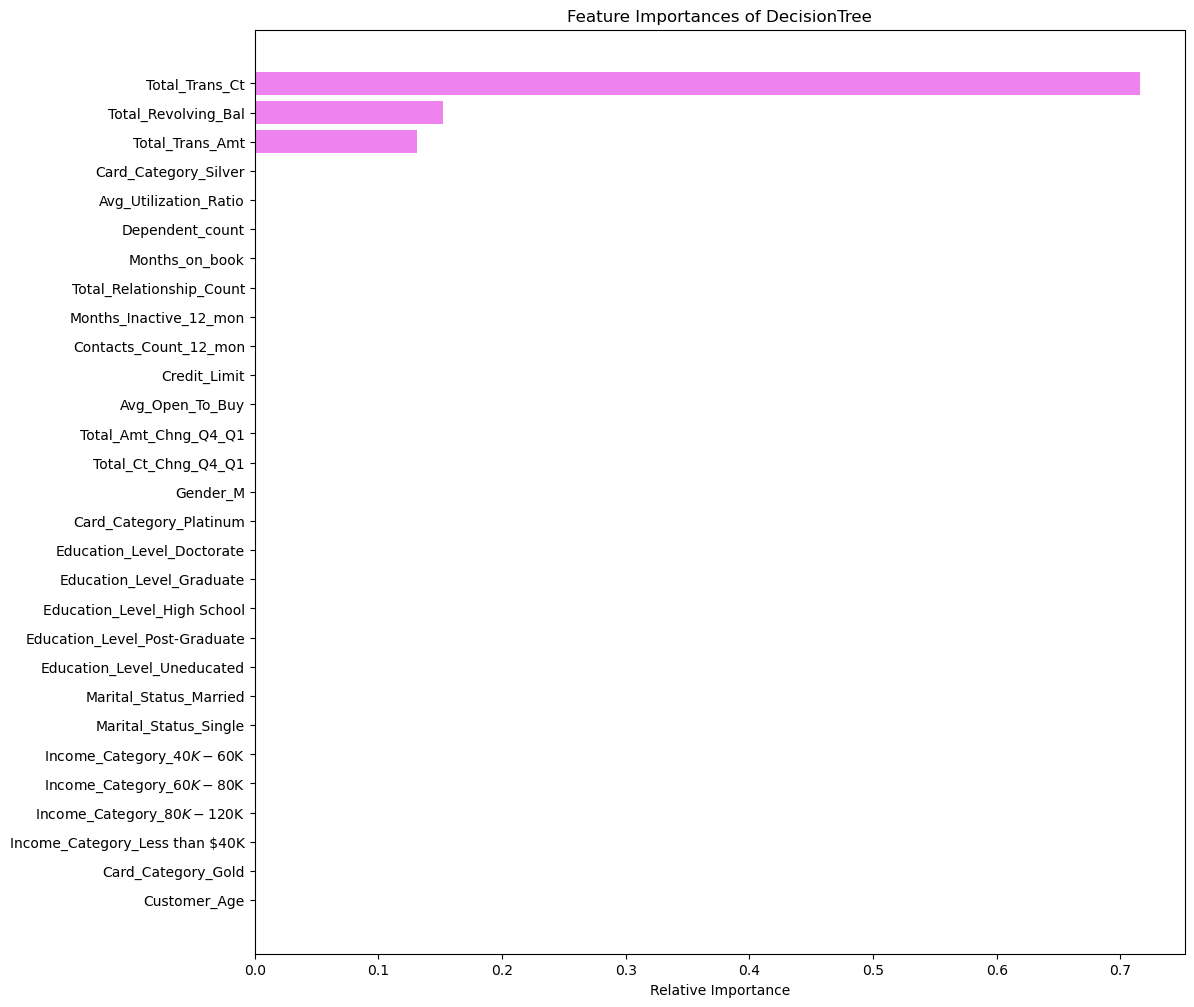

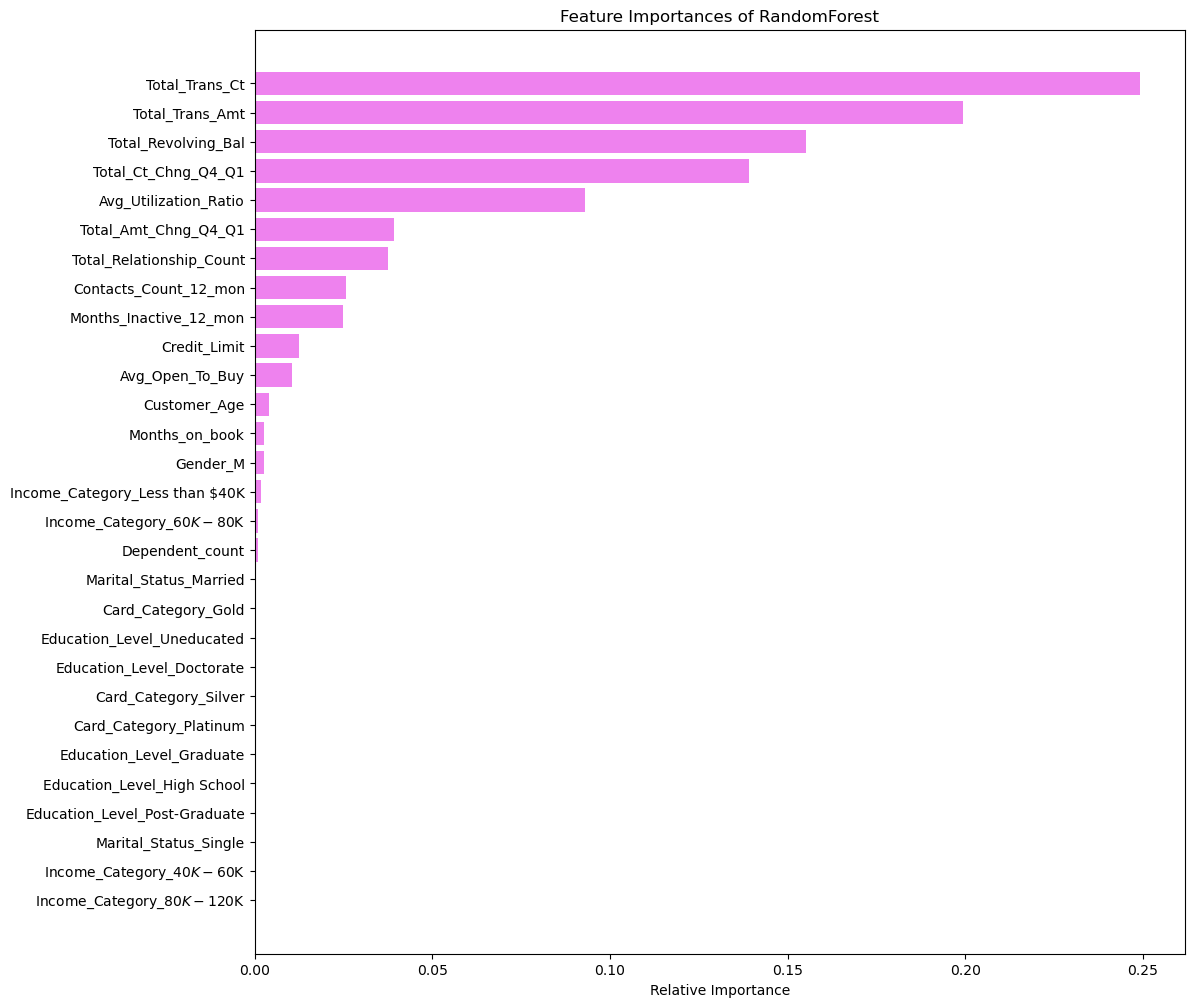

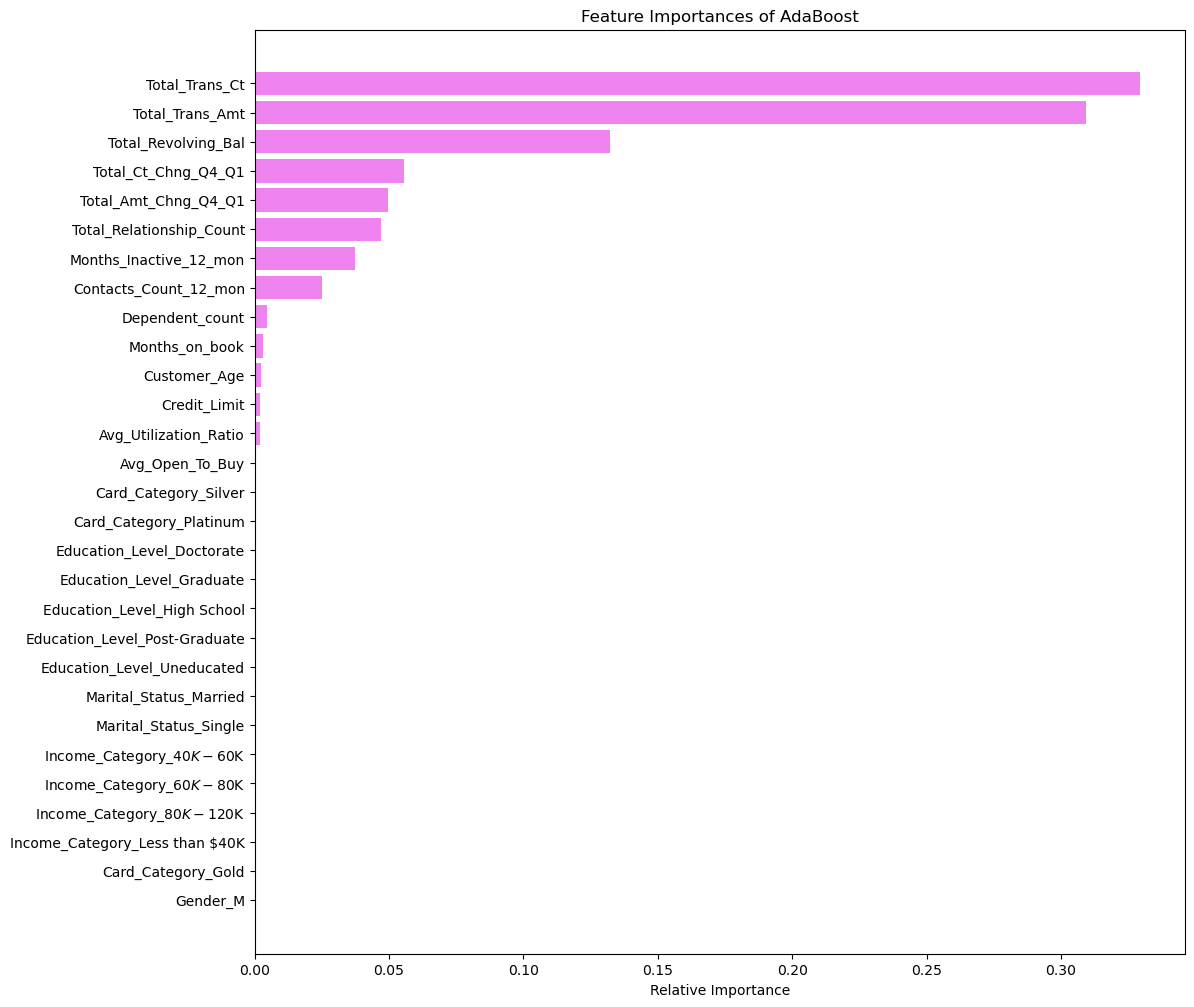

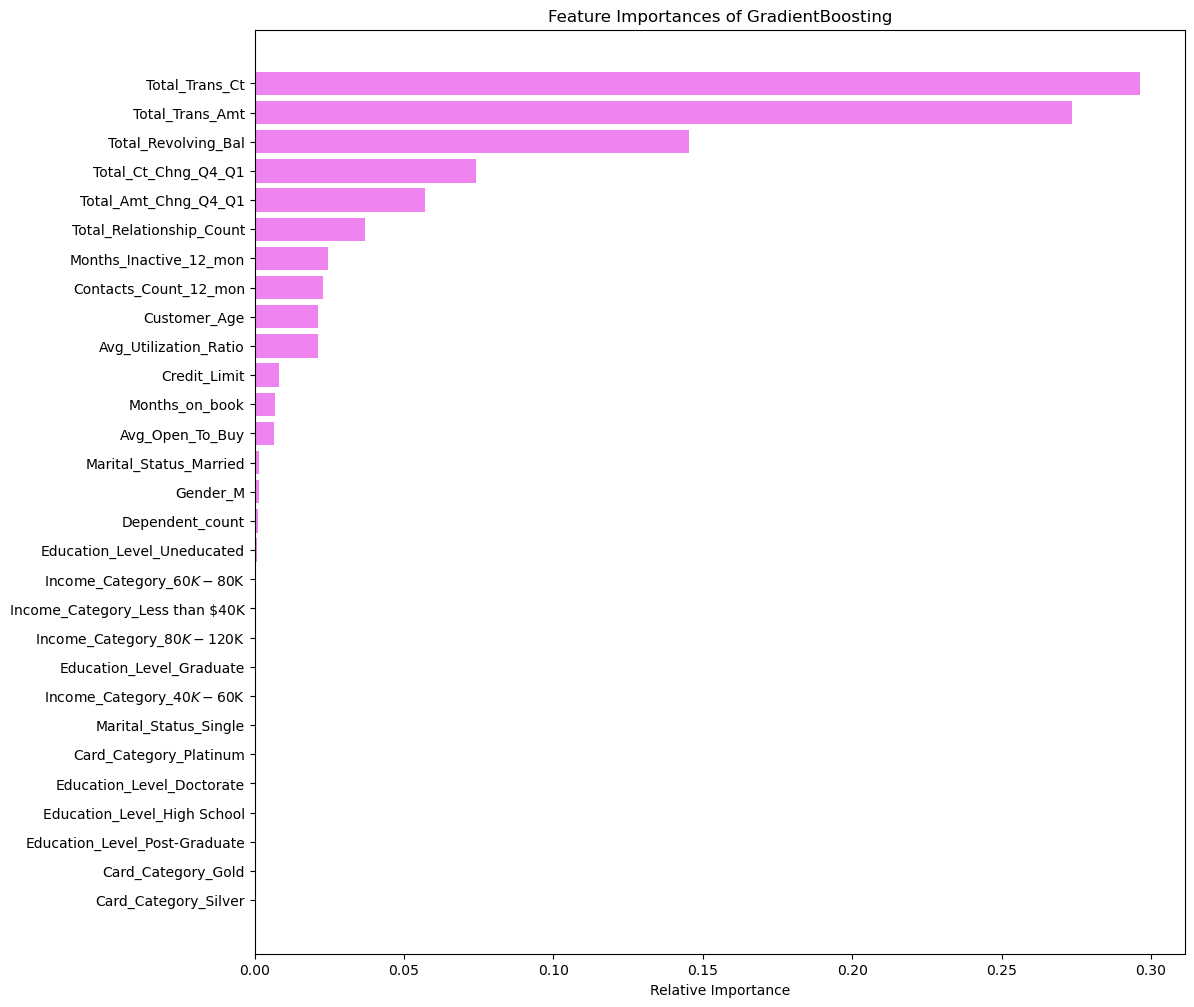

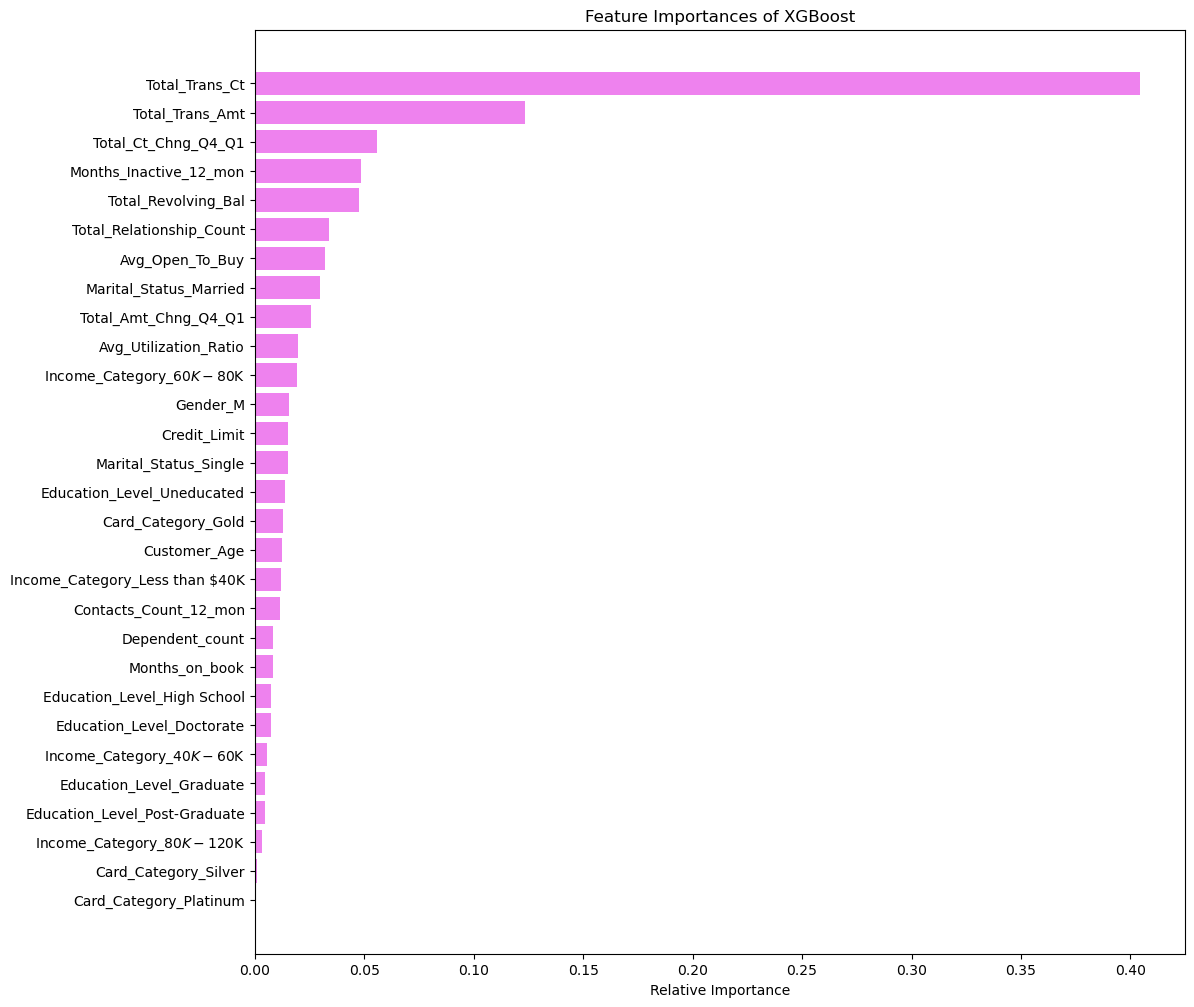

In [ ]:
# Get the column names of the training data to use as feature names
feature_names = X_train.columns

# Loop through each model in the list of best models to perform the final evaluation
for model in best_models:
    # Unpack the model tuple into name, resampling method, and base model instance
    model_name, resampling_selected, base_model = model

    # Skip the 'Bagging' model since it does not support feature importance
    if model_name == 'Bagging':
        continue

    # Extract the feature importance values from the model instance
    importances = base_model.feature_importances_

    # Get the indices of features sorted by their importance (from least to most important)
    indices = np.argsort(importances)

    # Create a new figure for visualization
    plt.figure(figsize=(12, 12))
    # Set the title of the plot, indicating which model's feature importances are being visualized
    plt.title(f"Feature Importances of {model_name}")

    # Plot a horizontal bar chart with the sorted feature importances
    # The height of each bar corresponds to the importance value of the respective feature
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")

    # Set the labels for each bar using the sorted feature names
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

    # Label the x-axis to indicate that the values represent the relative importance of features
    plt.xlabel("Relative Importance")

    # Display the plot
    plt.show()

**Key Features Across Models**

An analysis of feature importance across most models highlights three features that consistently play a crucial role in predicting outcomes. These features are:
- Total_Trans_Ct: The total number of transactions, indicating user activity and engagement.
- Total_Trans_Amount: The total monetary value of transactions, reflecting the overall spending behavior.
- Total_Revolving_Bal: The revolving balance amount, which can signal financial behavior such as credit utilization or outstanding debt.

These features demonstrate their significance by consistently ranking high in feature importance scores, suggesting they have a substantial impact on model predictions across multiple configurations.

# Business Insights and Conclusions

## 1. Business Insights & Key Drivers of Churn

**High Transaction Engagement → Lower Churn**
- Customers with more transactions and spending (Total_Trans_Ct, Total_Trans_Amt) are far less likely to attrite.
- A drop in transaction count or amount from Q1 to Q4 (Total_Ct_Chng_Q4_Q1, Total_Amt_Chng_Q4_Q1) strongly predicts churn.

**Carrying Some Revolving Balance Indicates Continued Usage**
- Total_Revolving_Bal: Churners often have little to no revolving balance, suggesting they’re not actively using the card.

**Utilization & Open‐to‐Buy**
- Moderate Avg_Utilization_Ratio often correlates with lower churn (active usage).
- Extremely low utilization (near 0) can signal disengagement.

**Multiple Banking Products**
- Total_Relationship_Count: Customers with 4+ products (e.g., checking, savings, loans) are “stickier” and less likely to leave.

**High Contact Frequency Can Be a Red Flag**
- Contacts_Count_12_mon: Very frequent contacts (5–6 times) correlate with higher churn—possibly due to unresolved service issues.

**Demographics & Simple Tenure Are Less Predictive**
- Age, income, marital status, education, and months_on_book show small differences in churn.
- Engagement (transactions, usage) outweighs demographics as a churn predictor.

## 2. Answers to Key Business Questions

**Why are customers leaving?**
- They tend to stop using the card over time, either showing falling transactions/spend or minimal revolving balance. Service frustration could also be signaled by high contact frequency.

**Which customers are at highest risk?**
- Those whose transaction count or amount has sharply dropped from Q1 to Q4.
- Zero or very low card usage (Avg_Utilization_Ratio near 0).
- 1–2 total products with the bank (not deeply engaged).
- High contact customers (5–6 calls) may be dissatisfied.

**How can the bank intervene?**
- Targeted Retention Offers: Incentivize dormant or lightly using customers to transact more frequently (e.g., tailored rewards, fee waivers).
- Early Warning on Service Issues: High contact frequency could trigger a priority follow‐up to resolve complaints.

## 3. Model Performance Overview

**Recall Priority**
- For churn detection, recall is critical: you want to catch as many potential churners as possible to intervene. Models like XGBoost (0.9938), Bagging (1.0000), Decision Tree (0.9594), and Gradient Boosting (0.9375) all have very high recalls.

**Precision & F1 Matter Too**
- If precision is too low, you’ll waste resources on many false positives. Bagging, for instance, flags nearly everyone as a churner (precision 0.16), leading to poor F1 (0.27). That’s not practical.
- XGBoost also has a relatively low precision (0.40), which might be expensive if you’re intervening with most of your customer base.
- GradientBoosting (precision ≈ 0.70, recall ≈ 0.94, F1 ≈ 0.80) strikes an excellent balance—it catches the vast majority of churners while keeping false alarms moderate.

**Best Balanced Model**
- Gradient Boosting emerges as a top choice given its high recall (0.9375) and best overall F1 (0.8021).
- AdaBoost also performs well (F1 ≈ 0.77), but slightly lower precision than Gradient Boosting.

**Recommended Model**
- Select Gradient Boosting
    - It offers a strong balance of recall (captures most churners) and precision (keeps false positives manageable).
    - Higher accuracy and best F1 among these models suggest it should generalize well.